# 05 - Deep models

Four sequence models over the same windows, each adding one block of features, so
the ablation isolates what each block buys.

| Exp | Input | Architecture | Features |
|-----|-------|--------------|----------|
| M1 | basic kinematics | BiLSTM | 43: keypoint speeds and angles |
| M2 | + implicit Δz | BiLSTM | 51: M1 plus 8 per-segment Δz |
| M3 | + relational | BiLSTM | 64: M2 plus 13 inter-mouse features |
| M4 | skeleton graph | GATv2 + BiLSTM | 5 per node, 7 nodes, 2 mice |

Sections §2 to §16 run on a single video and are illustrative. The reportable
numbers are in **§A1** onwards: leave-one-video-out over 20 videos with the official
metric.

## §1 Imports and configuration

In [1]:
import sys, os
sys.path.insert(0, '..')  # project root

import numpy as np
import pandas as pd
import h5py
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score

from src.models.rnn import BehaviorLSTM, FocalLoss
from src.models.graph import BehaviorSkeletonGNN, _TG_AVAILABLE
from src.train import fit
from src.data.dataset import MouseBehaviorDataset, LabelEncoder

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device} | torch: {torch.__version__} | TG: {_TG_AVAILABLE}')

CHECKPOINT_DIR = '../results/checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)


Device: cpu | torch: 2.11.0+cpu | TG: True


## §2 Loading from the HDF5 cache (single video, illustrative)

> **High variance. Not the headline.** §2 to §16 train and evaluate on one video
> (`CalMS21_task1_13638642`), with a test set of a few dozen windows and several
> classes at zero support. They show the architectures and the pipeline; they cannot
> rank models. The reportable numbers are in **§A1**.

In [2]:
H5_PATH = '../dataset/features/CalMS21_task1_13638642_features.h5'

with h5py.File(H5_PATH, 'r') as f:
    X_full_m1 = f['mouse_1/X'][:].astype(np.float32)  # (N, T, 64)
    X_full_m2 = f['mouse_2/X'][:].astype(np.float32)
    y_raw      = f['mouse_1/y'][:]
    idx_tr     = f['split/train'][:]
    idx_va     = f['split/val'][:]
    idx_te     = f['split/test'][:]
    feat_names = f['mouse_1'].attrs['feature_names'].split('|')

print(f'X_m1: {X_full_m1.shape}  X_m2: {X_full_m2.shape}')
print(f'Splits → tr={len(idx_tr)}, va={len(idx_va)}, te={len(idx_te)}')
print(f'Feature names (primeras 5): {feat_names[:5]}')


X_m1: (357, 64, 64)  X_m2: (357, 64, 64)
Splits → tr=249, va=54, te=54
Feature names (primeras 5): ['centroid_x', 'centroid_y', 'centroid_vx', 'centroid_vy', 'centroid_speed']


## §3 Label encoding

In [3]:
labels_raw = [v.decode() if isinstance(v, bytes) else str(v) for v in y_raw]
# Leave 'background' out of the encoder; MouseBehaviorDataset filters it
classes = sorted(c for c in set(labels_raw) if c != 'background')
print('Behaviour classes:', classes)

enc = LabelEncoder(classes=classes, background_label='background')
y = enc.encode(labels_raw)  # background -> -1, the rest -> 0..N-1
N_CLASSES = enc.n_classes
print(f'N_CLASSES = {N_CLASSES}  (background filtered out in the Dataset)')

# Window distribution per class
from collections import Counter
dist = Counter(labels_raw)
for cls, cnt in sorted(dist.items()):
    print(f'  {cls:20s}: {cnt:4d}  ({100*cnt/len(labels_raw):.1f}%)')


Clases de comportamiento: ['approach', 'mount', 'sniffbody', 'sniffface', 'sniffgenital']
N_CLASSES = 5  (background filtrado en Dataset)
  approach            :   31  (8.7%)
  background          :  149  (41.7%)
  mount               :   41  (11.5%)
  sniffbody           :   73  (20.4%)
  sniffface           :   31  (8.7%)
  sniffgenital        :   32  (9.0%)


## §4 Feature slices for M1 to M3

In [4]:
# Feature slices, one per ablation arm
X_m1 = X_full_m1[:, :, :43]   # basic kinematics
X_m2 = X_full_m1[:, :, :51]   # plus dz
X_m3 = X_full_m1               # every feature

def make_loaders(X, y, idx_tr, idx_va, idx_te, bs=32, seed=SEED):
    g = torch.Generator().manual_seed(seed)
    ds_tr = MouseBehaviorDataset(X[idx_tr], y[idx_tr])
    ds_va = MouseBehaviorDataset(X[idx_va], y[idx_va])
    ds_te = MouseBehaviorDataset(X[idx_te], y[idx_te])
    dl_tr = DataLoader(ds_tr, batch_size=bs, shuffle=True,  num_workers=0, generator=g)
    dl_va = DataLoader(ds_va, batch_size=bs, shuffle=False, num_workers=0)
    dl_te = DataLoader(ds_te, batch_size=bs, shuffle=False, num_workers=0)
    return dl_tr, dl_va, dl_te

dl_m1_tr, dl_m1_va, dl_m1_te = make_loaders(X_m1, y, idx_tr, idx_va, idx_te)
dl_m2_tr, dl_m2_va, dl_m2_te = make_loaders(X_m2, y, idx_tr, idx_va, idx_te)
dl_m3_tr, dl_m3_va, dl_m3_te = make_loaders(X_m3, y, idx_tr, idx_va, idx_te)
print(f'M1: {X_m1.shape[2]} feats | M2: {X_m2.shape[2]} feats | M3: {X_m3.shape[2]} feats')


M1: 43 feats | M2: 51 feats | M3: 64 feats


## §5 Per-node features for M4

Reorganises the cached features into per-node tensors:

- **4 dynamic features** per node: `[vx, vy, speed, accel]`
- **1 Δz feature** per node: the mean Δz of the edges meeting at it

That gives `(N, T=64, V=7, n_feat=5)` per mouse, built from the existing cache
rather than by reprocessing the tracking Parquet files.

In [5]:
KEYPOINTS = ['nose', 'neck', 'ear_left', 'ear_right',
             'hip_left', 'hip_right', 'tail_base']
V = len(KEYPOINTS)

# Starting index of {vx, vy, speed, accel} per keypoint in the 64-feature vector
KP_FEAT_START = {
    'nose':      9,
    'neck':      13,
    'ear_left':  17,
    'ear_right': 21,
    'hip_left':  25,
    'hip_right': 29,
    'tail_base': 33,
}
# dz edges adjacent to each node, as indices into the 64-feature vector
NODE_DZ_EDGES = {
    'nose':      [43],
    'neck':      [43, 44, 45, 46, 47],
    'ear_left':  [44],
    'ear_right': [45],
    'hip_left':  [46, 48],
    'hip_right': [47, 49],
    'tail_base': [48, 49],
}

def build_node_features(X_flat: np.ndarray) -> np.ndarray:
    """(N, T, 64) -> (N, T, V=7, n_feat=5)"""
    N, T, _ = X_flat.shape
    X_node = np.zeros((N, T, V, 5), dtype=np.float32)
    for vi, kp in enumerate(KEYPOINTS):
        fs = KP_FEAT_START[kp]
        X_node[:, :, vi, :4] = X_flat[:, :, fs:fs+4]
        dz_idx = NODE_DZ_EDGES[kp]
        X_node[:, :, vi, 4]  = X_flat[:, :, dz_idx].mean(axis=-1)
    return X_node

X_node_m1 = build_node_features(X_full_m1)  # (357, 64, 7, 5)
X_node_m2 = build_node_features(X_full_m2)
print(f'X_node_m1: {X_node_m1.shape}  X_node_m2: {X_node_m2.shape}')


X_node_m1: (357, 64, 7, 5)  X_node_m2: (357, 64, 7, 5)


## §6 DataLoaders for M4

In [6]:
# Concatenate both mice along the node dimension -> (N, T, 14, 5).
# A wrapper splits them again internally before they reach the GNN.
X_gnn = np.concatenate([X_node_m1, X_node_m2], axis=2)  # (N, T, 14, 5)


class _GNNWrapper(nn.Module):
    """Adapt BehaviorSkeletonGNN to the fit() API, which passes a single tensor."""
    def __init__(self, gnn: nn.Module, n_nodes: int = 7):
        super().__init__()
        self.gnn = gnn
        self.n_nodes = n_nodes

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (N, T, 2*V, n_feat)
        V = self.n_nodes
        return self.gnn(x[:, :, :V, :], x[:, :, V:, :])


dl_m4_tr, dl_m4_va, dl_m4_te = make_loaders(X_gnn, y, idx_tr, idx_va, idx_te, bs=16)
print(f'M4 tensor shape per sample: {X_gnn.shape[1:]}')


M4 tensor shape per sample: (64, 14, 5)


## §7 Evaluation helpers

In [7]:
def evaluate_model(model, loader, enc, device, title=''):
    """Evaluate over a DataLoader: classification report plus confusion matrix."""
    model.eval()
    all_pred, all_true = [], []
    with torch.no_grad():
        for x, y_batch in loader:
            x = x.to(device)
            x = torch.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
            logits = model(x)
            all_pred.extend(logits.argmax(-1).cpu().numpy())
            all_true.extend(y_batch.numpy())
    print(f'\n=== {title} ===')
    # Pin the full class space: if a class is absent from this split, sklearn would
    # infer fewer labels than target_names and raise ValueError.
    _labels = list(range(len(enc.classes)))
    print(classification_report(
        all_true, all_pred,
        labels=_labels,
        target_names=enc.classes,
        zero_division=0,
    ))
    macro_f1 = f1_score(all_true, all_pred, average='macro', zero_division=0)

    cm = confusion_matrix(all_true, all_pred, labels=_labels)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=enc.classes, yticklabels=enc.classes, ax=ax)
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')
    ax.set_title(f'{title}  —  F1-macro={macro_f1:.3f}')
    plt.tight_layout()
    plt.show()
    return macro_f1


def plot_history(history: dict, title: str = ''):
    """Validation loss and F1 curves."""
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(history['train_loss'], label='train')
    axes[0].plot(history['val_loss'],   label='val')
    axes[0].set(title=f'{title} - loss', xlabel='epoch', ylabel='loss')
    axes[0].legend()
    axes[1].plot(history['val_f1'], label='val F1-macro')
    axes[1].set(title=f'{title} - val F1', xlabel='epoch', ylabel='F1')
    axes[1].legend()
    plt.tight_layout()
    plt.show()


## §8 M1: BiLSTM on kinematics only (43 features)

The deep baseline: per-keypoint speeds, accelerations and skeletal angles, and
nothing about the other mouse.

M1 params: 607,237
Epoch   1/80 | train_loss=3.3770  tr_f1=0.1616 | val_loss=1.7478  val_f1=0.1048 | lr=1.00e-03 | (0.7s) ★
Epoch   2/80 | train_loss=2.0337  tr_f1=0.2044 | val_loss=1.4847  val_f1=0.1048 | lr=9.98e-04 | (0.6s)
Epoch   3/80 | train_loss=1.8123  tr_f1=0.2238 | val_loss=1.5757  val_f1=0.2556 | lr=9.97e-04 | (0.6s) ★
Epoch   4/80 | train_loss=1.7376  tr_f1=0.1554 | val_loss=1.5420  val_f1=0.1444 | lr=9.94e-04 | (0.5s)
Epoch   5/80 | train_loss=1.6007  tr_f1=0.2094 | val_loss=1.3962  val_f1=0.2723 | lr=9.90e-04 | (0.5s) ★
Epoch   6/80 | train_loss=1.7899  tr_f1=0.1795 | val_loss=1.4048  val_f1=0.2933 | lr=9.86e-04 | (0.6s) ★
Epoch   7/80 | train_loss=1.6122  tr_f1=0.2293 | val_loss=1.3824  val_f1=0.2762 | lr=9.81e-04 | (0.5s)
Epoch   8/80 | train_loss=1.6624  tr_f1=0.2809 | val_loss=1.3928  val_f1=0.2556 | lr=9.76e-04 | (0.6s)
Epoch   9/80 | train_loss=1.6893  tr_f1=0.2213 | val_loss=1.5892  val_f1=0.2163 | lr=9.69e-04 | (0.6s)
Epoch  10/80 | train_loss=1.5706  tr_f1=0.2134

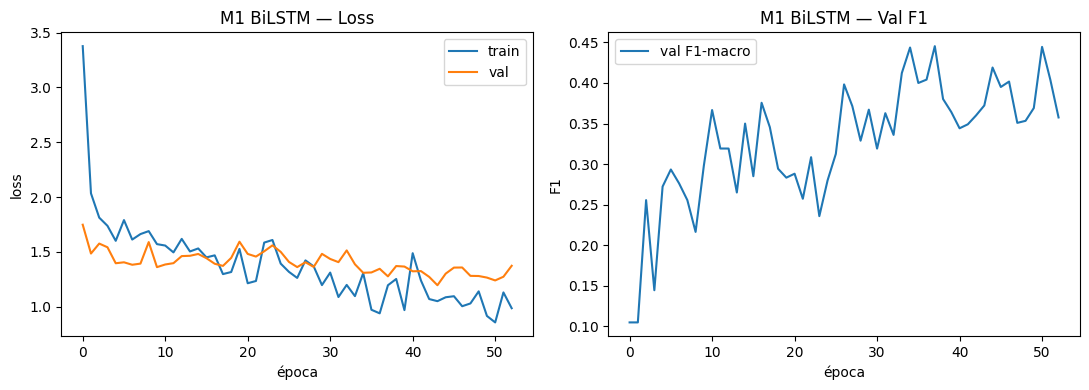

In [8]:
model_m1 = BehaviorLSTM(
    input_size=43,
    hidden_size=128,
    num_layers=2,
    n_classes=N_CLASSES,
    dropout=0.3,
    bidirectional=True,
    use_attention=True,
).to(device)

print(f'M1 params: {sum(p.numel() for p in model_m1.parameters()):,}')

hist_m1 = fit(
    model_m1, dl_m1_tr, dl_m1_va,
    epochs=80,
    lr=1e-3,
    weight_decay=1e-4,
    patience=15,
    device=device,
    augment=True,
    mixup_alpha=0.4,
    checkpoint_path=f'{CHECKPOINT_DIR}/m1_bilstm_calms21.pt',
    verbose=True,
)
plot_history(hist_m1, 'M1 BiLSTM')



=== M1 — Test ===
              precision    recall  f1-score   support

    approach       0.00      0.00      0.00         5
       mount       0.80      0.67      0.73         6
   sniffbody       0.48      0.91      0.62        11
   sniffface       0.00      0.00      0.00         5
sniffgenital       0.20      0.20      0.20         5

    accuracy                           0.47        32
   macro avg       0.30      0.36      0.31        32
weighted avg       0.34      0.47      0.38        32



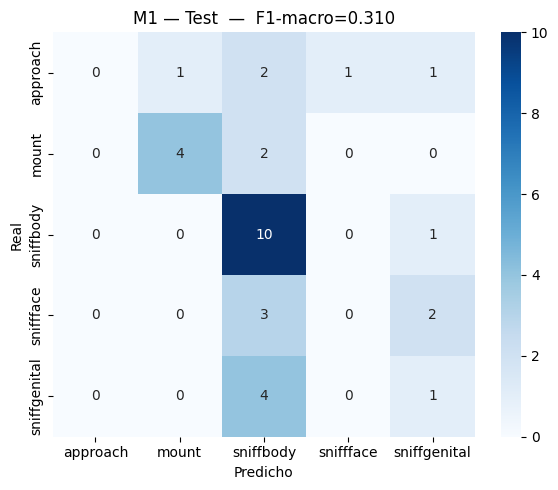

In [9]:
# Cargar mejor checkpoint
model_m1.load_state_dict(torch.load(
    f'{CHECKPOINT_DIR}/m1_bilstm_calms21.pt', map_location=device, weights_only=True
))
f1_m1 = evaluate_model(model_m1, dl_m1_te, enc, device, 'M1 — Test')


## §9 M2: adding implicit Δz (51 features)

Adds the 8 Δz estimates, one per skeleton edge, to test whether inferred depth
carries usable signal.

M2 params: 615,429
Epoch   1/80 | train_loss=2.7281  tr_f1=0.2063 | val_loss=1.9771  val_f1=0.1073 | lr=1.00e-03 | (0.6s) ★
Epoch   2/80 | train_loss=1.9004  tr_f1=0.3225 | val_loss=1.2406  val_f1=0.3896 | lr=9.98e-04 | (0.6s) ★
Epoch   3/80 | train_loss=1.2930  tr_f1=0.3166 | val_loss=1.2476  val_f1=0.3332 | lr=9.97e-04 | (0.5s)
Epoch   4/80 | train_loss=1.0459  tr_f1=0.4440 | val_loss=1.0507  val_f1=0.5472 | lr=9.94e-04 | (0.6s) ★
Epoch   5/80 | train_loss=1.1370  tr_f1=0.3287 | val_loss=1.1690  val_f1=0.4794 | lr=9.90e-04 | (0.5s)
Epoch   6/80 | train_loss=0.9386  tr_f1=0.4257 | val_loss=1.0382  val_f1=0.6571 | lr=9.86e-04 | (0.6s) ★
Epoch   7/80 | train_loss=0.9567  tr_f1=0.4922 | val_loss=1.0614  val_f1=0.5455 | lr=9.81e-04 | (0.5s)
Epoch   8/80 | train_loss=0.8985  tr_f1=0.3038 | val_loss=0.8977  val_f1=0.6964 | lr=9.76e-04 | (0.6s) ★
Epoch   9/80 | train_loss=1.3077  tr_f1=0.4043 | val_loss=0.9521  val_f1=0.6162 | lr=9.69e-04 | (0.6s)
Epoch  10/80 | train_loss=0.9729  tr_f1=0.32

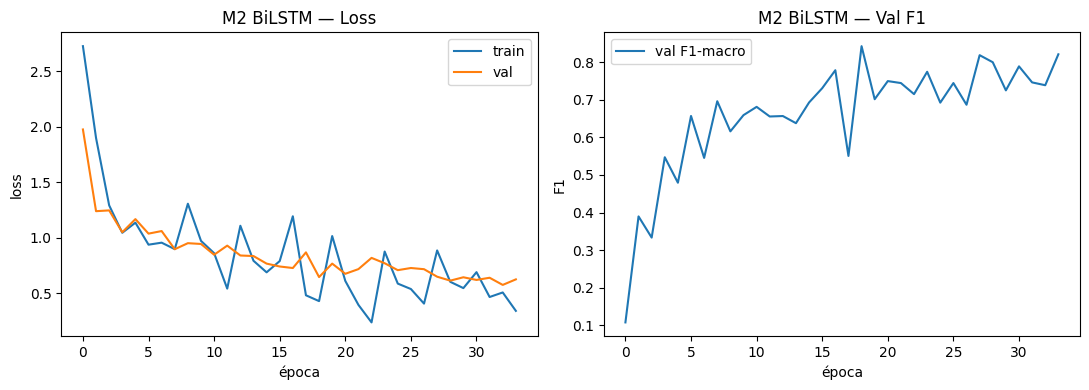

In [10]:
model_m2 = BehaviorLSTM(
    input_size=51,
    hidden_size=128,
    num_layers=2,
    n_classes=N_CLASSES,
    dropout=0.3,
    bidirectional=True,
    use_attention=True,
).to(device)

print(f'M2 params: {sum(p.numel() for p in model_m2.parameters()):,}')

hist_m2 = fit(
    model_m2, dl_m2_tr, dl_m2_va,
    epochs=80,
    lr=1e-3,
    weight_decay=1e-4,
    patience=15,
    device=device,
    augment=True,
    mixup_alpha=0.4,
    checkpoint_path=f'{CHECKPOINT_DIR}/m2_bilstm_calms21.pt',
    verbose=True,
)
plot_history(hist_m2, 'M2 BiLSTM')



=== M2 — Test ===
              precision    recall  f1-score   support

    approach       0.83      1.00      0.91         5
       mount       0.86      1.00      0.92         6
   sniffbody       0.77      0.91      0.83        11
   sniffface       1.00      0.80      0.89         5
sniffgenital       1.00      0.40      0.57         5

    accuracy                           0.84        32
   macro avg       0.89      0.82      0.83        32
weighted avg       0.87      0.84      0.83        32



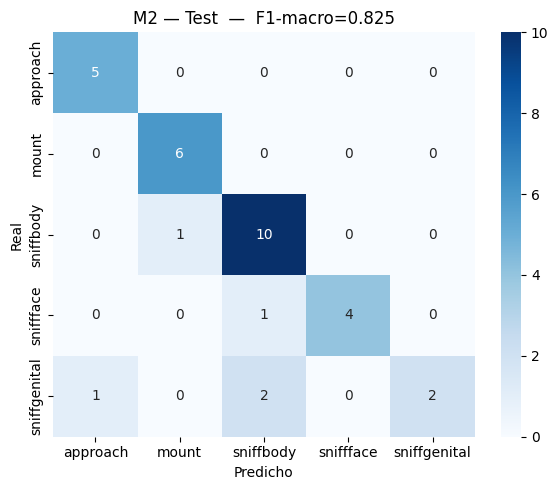

In [11]:
model_m2.load_state_dict(torch.load(
    f'{CHECKPOINT_DIR}/m2_bilstm_calms21.pt', map_location=device, weights_only=True
))
f1_m2 = evaluate_model(model_m2, dl_m2_te, enc, device, 'M2 — Test')


## §10 M3: all features (64)

Adds the 13 inter-mouse relational features. This is the deep counterpart of the B4
and B5 baselines in notebook 04.

M3 params: 628,741
Epoch   1/80 | train_loss=2.2620  tr_f1=0.1957 | val_loss=1.7177  val_f1=0.2614 | lr=1.00e-03 | (0.5s) ★
Epoch   2/80 | train_loss=1.4923  tr_f1=0.4758 | val_loss=1.2046  val_f1=0.5519 | lr=9.98e-04 | (0.5s) ★
Epoch   3/80 | train_loss=1.5101  tr_f1=0.4622 | val_loss=1.1479  val_f1=0.4905 | lr=9.97e-04 | (0.5s)
Epoch   4/80 | train_loss=0.9693  tr_f1=0.4691 | val_loss=1.0724  val_f1=0.6048 | lr=9.94e-04 | (0.5s) ★
Epoch   5/80 | train_loss=1.2731  tr_f1=0.5302 | val_loss=1.2938  val_f1=0.4528 | lr=9.90e-04 | (0.5s)
Epoch   6/80 | train_loss=0.7053  tr_f1=0.5611 | val_loss=0.9588  val_f1=0.5910 | lr=9.86e-04 | (0.5s)
Epoch   7/80 | train_loss=1.0424  tr_f1=0.3914 | val_loss=1.1284  val_f1=0.6517 | lr=9.81e-04 | (0.5s) ★
Epoch   8/80 | train_loss=0.9636  tr_f1=0.4627 | val_loss=0.9502  val_f1=0.7277 | lr=9.76e-04 | (0.5s) ★
Epoch   9/80 | train_loss=1.0834  tr_f1=0.6034 | val_loss=0.9193  val_f1=0.6767 | lr=9.69e-04 | (0.5s)
Epoch  10/80 | train_loss=1.0447  tr_f1=0.44

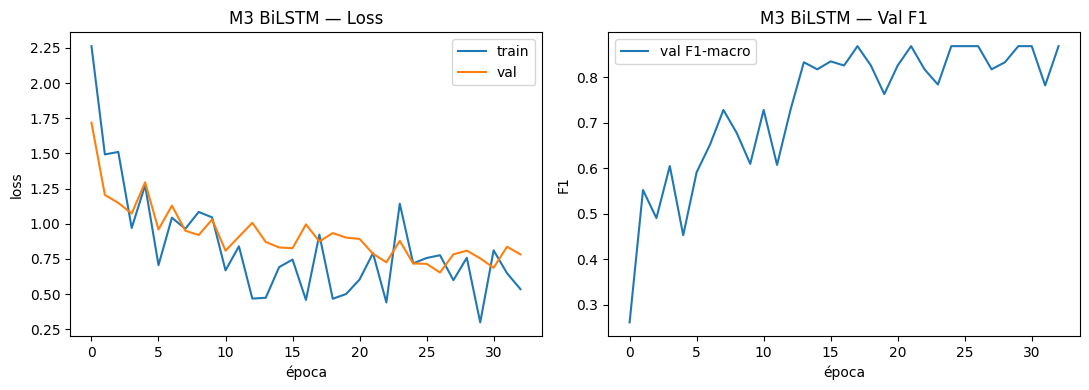

In [12]:
model_m3 = BehaviorLSTM(
    input_size=64,
    hidden_size=128,
    num_layers=2,
    n_classes=N_CLASSES,
    dropout=0.3,
    bidirectional=True,
    use_attention=True,
).to(device)

print(f'M3 params: {sum(p.numel() for p in model_m3.parameters()):,}')

hist_m3 = fit(
    model_m3, dl_m3_tr, dl_m3_va,
    epochs=80,
    lr=1e-3,
    weight_decay=1e-4,
    patience=15,
    device=device,
    augment=True,
    mixup_alpha=0.4,
    checkpoint_path=f'{CHECKPOINT_DIR}/m3_bilstm_calms21.pt',
    verbose=True,
)
plot_history(hist_m3, 'M3 BiLSTM')



=== M3 — Test ===
              precision    recall  f1-score   support

    approach       0.83      1.00      0.91         5
       mount       0.80      0.67      0.73         6
   sniffbody       0.60      0.82      0.69        11
   sniffface       0.50      0.40      0.44         5
sniffgenital       1.00      0.40      0.57         5

    accuracy                           0.69        32
   macro avg       0.75      0.66      0.67        32
weighted avg       0.72      0.69      0.68        32



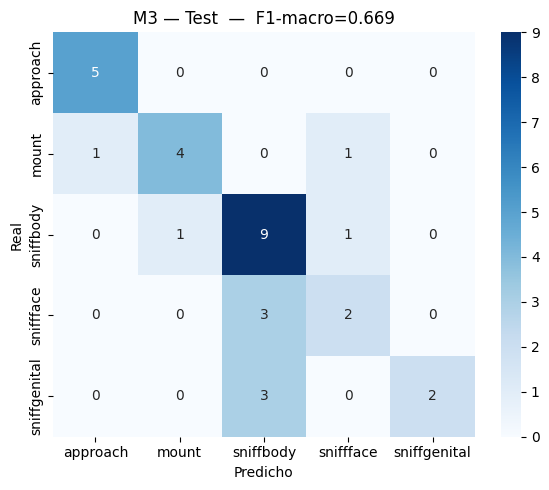

In [13]:
model_m3.load_state_dict(torch.load(
    f'{CHECKPOINT_DIR}/m3_bilstm_calms21.pt', map_location=device, weights_only=True
))
f1_m3 = evaluate_model(model_m3, dl_m3_te, enc, device, 'M3 — Test')


## §11 M4: GATv2 plus BiLSTM on the skeleton graph

> **Data limitation: this one does not move to 20 videos.** The GNN needs per-node
> keypoints per frame, and the honest 20-video caches store only the 64 aggregated
> features per window. M4 therefore stays in the single-video and 5-video regime and
> is **absent from the honest LOVO benchmark in §A1**. Including it would mean
> building a per-node keypoint cache over 20 videos.

The architecture is hierarchical:

1. **GATv2Conv** per frame, learning node representations with attention over the
   skeleton edges
2. **Global mean pool** to a per-frame posture embedding
3. **BiLSTM with temporal attention** over the posture sequence

The idea is to give the model the skeleton explicitly, as edges, instead of making
the LSTM infer which keypoints are connected. Both mice are processed separately and
their embeddings concatenated before the classification head.

In [14]:
gnn_base = BehaviorSkeletonGNN(
    n_feat=5,
    n_nodes=7,
    d_gnn=64,
    n_gat_layers=2,
    n_gat_heads=4,
    lstm_hidden=128,
    lstm_layers=2,
    n_classes=N_CLASSES,
    dropout=0.3,
    lab_type='calms21',
)
model_m4 = _GNNWrapper(gnn_base, n_nodes=7).to(device)
print(f'M4 params: {sum(p.numel() for p in model_m4.parameters()):,}')
print(f'TG (GATv2Conv real): {_TG_AVAILABLE}')


M4 params: 877,253
TG (GATv2Conv real): True


Epoch   1/100 | train_loss=2.6834  tr_f1=0.1673 | val_loss=2.1012  val_f1=0.1048 | lr=5.00e-04 | (5.2s) ★
Epoch   2/100 | train_loss=1.9057  tr_f1=0.2102 | val_loss=1.6079  val_f1=0.1048 | lr=5.00e-04 | (5.2s)
Epoch   3/100 | train_loss=1.9704  tr_f1=0.1675 | val_loss=1.5324  val_f1=0.1048 | lr=4.99e-04 | (4.8s)
Epoch   4/100 | train_loss=1.8290  tr_f1=0.2478 | val_loss=1.4733  val_f1=0.3238 | lr=4.98e-04 | (4.8s) ★
Epoch   5/100 | train_loss=1.7084  tr_f1=0.1931 | val_loss=1.4890  val_f1=0.1000 | lr=4.97e-04 | (4.9s)
Epoch   6/100 | train_loss=1.5879  tr_f1=0.2487 | val_loss=1.3854  val_f1=0.3546 | lr=4.96e-04 | (4.8s) ★
Epoch   7/100 | train_loss=1.9804  tr_f1=0.1857 | val_loss=1.4055  val_f1=0.3056 | lr=4.94e-04 | (5.0s)
Epoch   8/100 | train_loss=1.6791  tr_f1=0.2874 | val_loss=1.5685  val_f1=0.3251 | lr=4.92e-04 | (4.9s)
Epoch   9/100 | train_loss=1.7330  tr_f1=0.2636 | val_loss=1.4499  val_f1=0.1970 | lr=4.90e-04 | (4.9s)
Epoch  10/100 | train_loss=1.4411  tr_f1=0.2733 | val_loss

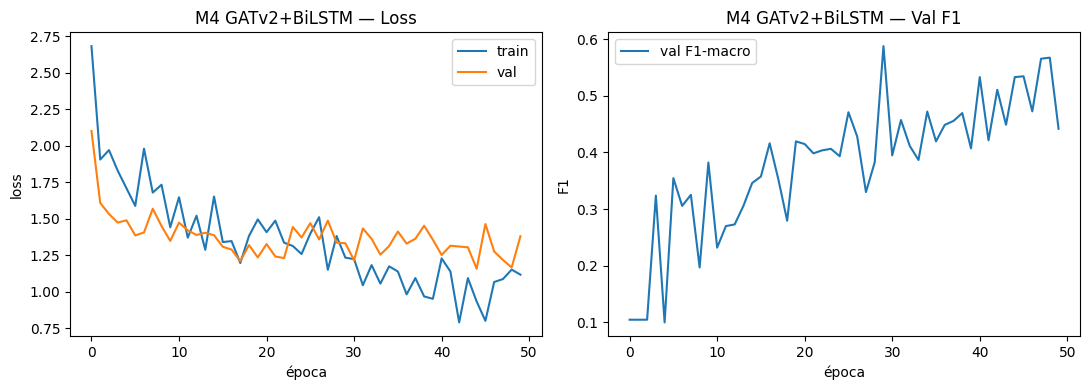

In [15]:
hist_m4 = fit(
    model_m4, dl_m4_tr, dl_m4_va,
    epochs=100,
    lr=5e-4,
    weight_decay=1e-4,
    patience=20,
    device=device,
    augment=True,
    mixup_alpha=0.3,
    checkpoint_path=f'{CHECKPOINT_DIR}/m4_gnn_calms21.pt',
    verbose=True,
)
plot_history(hist_m4, 'M4 GATv2+BiLSTM')



=== M4 — Test ===
              precision    recall  f1-score   support

    approach       0.44      0.80      0.57         5
       mount       0.62      0.83      0.71         6
   sniffbody       0.55      0.55      0.55        11
   sniffface       0.50      0.20      0.29         5
sniffgenital       0.50      0.20      0.29         5

    accuracy                           0.53        32
   macro avg       0.52      0.52      0.48        32
weighted avg       0.53      0.53      0.50        32



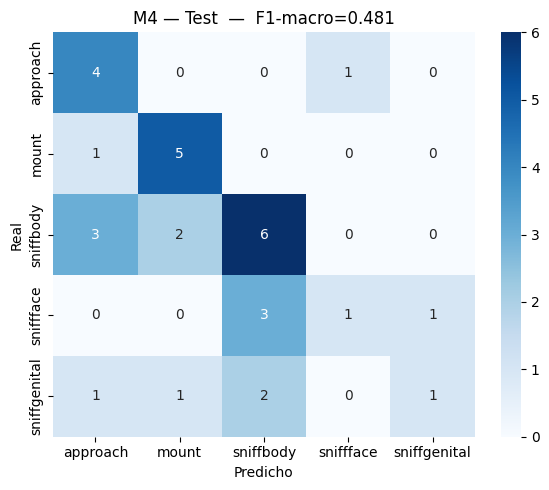

In [16]:
model_m4.load_state_dict(torch.load(
    f'{CHECKPOINT_DIR}/m4_gnn_calms21.pt', map_location=device, weights_only=True
))
f1_m4 = evaluate_model(model_m4, dl_m4_te, enc, device, 'M4 — Test')


## §12 Hyperparameter search

Grid search over `hidden_size`, `dropout` and `n_layers` for the full-feature model
(M3).

In [17]:
from itertools import product

HP_GRID = {
    'hidden_size': [64, 128, 256],
    'dropout':     [0.2, 0.3, 0.4],
    'n_layers':    [1, 2],
}

hp_results = []

for hs, dr, nl in product(HP_GRID['hidden_size'],
                           HP_GRID['dropout'],
                           HP_GRID['n_layers']):
    m = BehaviorLSTM(
        input_size=64, hidden_size=hs, num_layers=nl,
        n_classes=N_CLASSES, dropout=dr,
        bidirectional=True, use_attention=True,
    ).to(device)
    h = fit(
        m, dl_m3_tr, dl_m3_va,
        epochs=50, lr=1e-3, weight_decay=1e-4, patience=10,
        device=device, augment=True, mixup_alpha=0.4, verbose=False,
    )
    best_val_f1 = max(h['val_f1'])
    hp_results.append({
        'hidden_size': hs, 'dropout': dr, 'n_layers': nl,
        'best_val_f1': round(best_val_f1, 4),
    })
    print(f'hs={hs:3d} dr={dr} nl={nl}  val_F1={best_val_f1:.3f}')

df_hp = pd.DataFrame(hp_results).sort_values('best_val_f1', ascending=False)
print('\nTop-5:')
print(df_hp.head().to_string(index=False))


hs= 64 dr=0.2 nl=1  val_F1=0.635
hs= 64 dr=0.2 nl=2  val_F1=0.775
hs= 64 dr=0.3 nl=1  val_F1=0.502
hs= 64 dr=0.3 nl=2  val_F1=0.825
hs= 64 dr=0.4 nl=1  val_F1=0.656
hs= 64 dr=0.4 nl=2  val_F1=0.784
hs=128 dr=0.2 nl=1  val_F1=0.817
hs=128 dr=0.2 nl=2  val_F1=0.850
hs=128 dr=0.3 nl=1  val_F1=0.671
hs=128 dr=0.3 nl=2  val_F1=0.801
hs=128 dr=0.4 nl=1  val_F1=0.825
hs=128 dr=0.4 nl=2  val_F1=0.868
hs=256 dr=0.2 nl=1  val_F1=0.868
hs=256 dr=0.2 nl=2  val_F1=0.868
hs=256 dr=0.3 nl=1  val_F1=0.825
hs=256 dr=0.3 nl=2  val_F1=0.903
hs=256 dr=0.4 nl=1  val_F1=0.794
hs=256 dr=0.4 nl=2  val_F1=0.868

Top-5:
 hidden_size  dropout  n_layers  best_val_f1
         256      0.3         2       0.9029
         256      0.2         1       0.8678
         256      0.4         2       0.8678
         256      0.2         2       0.8678
         128      0.4         2       0.8678


Mejor config: hidden=256 dr=0.3 nl=2
Epoch   1/100 | train_loss=4.1919  tr_f1=0.1835 | val_loss=3.1326  val_f1=0.2872 | lr=1.00e-03 | (1.2s) ★
Epoch   2/100 | train_loss=1.8546  tr_f1=0.2820 | val_loss=1.4442  val_f1=0.5881 | lr=9.99e-04 | (1.2s) ★
Epoch   3/100 | train_loss=1.3288  tr_f1=0.3098 | val_loss=1.1996  val_f1=0.3771 | lr=9.98e-04 | (1.2s)
Epoch   4/100 | train_loss=1.5533  tr_f1=0.4327 | val_loss=1.0347  val_f1=0.5086 | lr=9.96e-04 | (1.1s)
Epoch   5/100 | train_loss=1.0756  tr_f1=0.3836 | val_loss=1.0094  val_f1=0.5443 | lr=9.94e-04 | (1.1s)
Epoch   6/100 | train_loss=1.1800  tr_f1=0.3260 | val_loss=0.9010  val_f1=0.6752 | lr=9.91e-04 | (1.2s) ★
Epoch   7/100 | train_loss=0.6221  tr_f1=0.6203 | val_loss=0.9484  val_f1=0.7438 | lr=9.88e-04 | (1.2s) ★
Epoch   8/100 | train_loss=0.6245  tr_f1=0.3149 | val_loss=0.9616  val_f1=0.7347 | lr=9.84e-04 | (1.2s)
Epoch   9/100 | train_loss=1.1102  tr_f1=0.6251 | val_loss=0.9594  val_f1=0.8018 | lr=9.80e-04 | (1.2s) ★
Epoch  10/100 | t

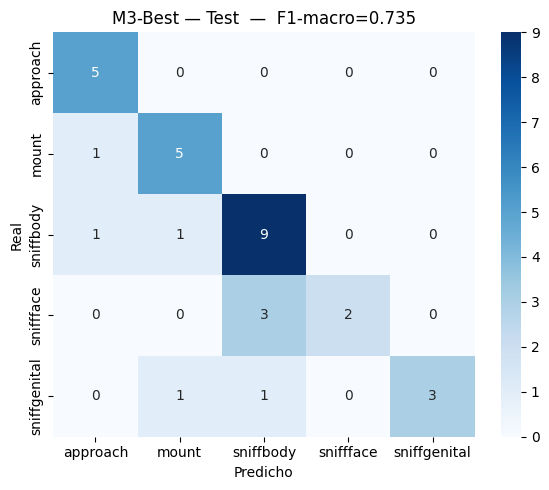

In [18]:
# Train the best configuration and evaluate on the test set
best = df_hp.iloc[0]
print(f'Mejor config: hidden={int(best.hidden_size)} dr={best.dropout} nl={int(best.n_layers)}')

model_best = BehaviorLSTM(
    input_size=64,
    hidden_size=int(best.hidden_size),
    num_layers=int(best.n_layers),
    n_classes=N_CLASSES,
    dropout=float(best.dropout),
    bidirectional=True,
    use_attention=True,
).to(device)

hist_best = fit(
    model_best, dl_m3_tr, dl_m3_va,
    epochs=100, lr=1e-3, weight_decay=1e-4, patience=20,
    device=device, augment=True, mixup_alpha=0.4,
    checkpoint_path=f'{CHECKPOINT_DIR}/m3_best_calms21.pt',
    verbose=True,
)

model_best.load_state_dict(torch.load(
    f'{CHECKPOINT_DIR}/m3_best_calms21.pt', map_location=device, weights_only=True
))
f1_m3_best = evaluate_model(model_best, dl_m3_te, enc, device, 'M3-Best — Test')


## §13 Combined table: notebooks 04 and 05

In [19]:
# Load the earlier classical-baseline results
df_ph4 = pd.read_csv('../results/phase4_summary.csv')
print('Fase 4:')
print(df_ph4.to_string(index=False))


Fase 4:
         Configuración                                    Modelo N features  N ventanas F1-macro (CV)          Protocolo
             B1_raw_rf                             Random Forest        387         103 0.449 ± 0.040 StratifiedKFold CV
            B2_corr_rf                             Random Forest        387         103 0.504 ± 0.027 StratifiedKFold CV
              B3_dz_rf                             Random Forest        459         103 0.546 ± 0.080 StratifiedKFold CV
            B4_full_rf                             Random Forest        576         103 0.611 ± 0.087 StratifiedKFold CV
            B5_full_gb                      HistGradientBoosting        576         103 0.613 ± 0.037 StratifiedKFold CV
          M1_full_lstm                           BiLSTM+Atención         64         103         0.167  hold-out temporal
   M1_full_lstm_smooth                   BiLSTM+Atención+TSmooth         64         103         0.333  hold-out temporal
       M2_cnn_lstm_tta  

In [20]:
# Build the deep-model results row by row
results_ph5 = []

# Classical-baseline results, reusing the 'model' and 'test_f1_macro' columns
for _, row in df_ph4.iterrows():
# 'F1-macro (CV)' is formatted as '0.449 ± 0.040'; take the mean
    f1_str = str(row['F1-macro (CV)']).split('±')[0].strip()
    results_ph5.append({
    'model': row['Configuration'],
    'phase': 4,
    'n_features': row.get('N features', '—'),
    'test_f1_macro': float(f1_str),
    })

# Deep-model results
ph5_rows = [
    ('M1_bilstm',       5, 43,  f1_m1),
    ('M2_bilstm_dz',    5, 51,  f1_m2),
    ('M3_bilstm_full',  5, 64,  f1_m3),
    ('M4_gnn_bilstm',   5, '7n×5', f1_m4),
    ('M3_best_hp',      5, 64,  f1_m3_best),
]
for model_name, phase, nf, f1 in ph5_rows:
    results_ph5.append({
        'model': model_name,
        'phase': phase,
        'n_features': nf,
        'test_f1_macro': round(f1, 4),
    })

df_summary = pd.DataFrame(results_ph5)
df_summary = df_summary.sort_values('test_f1_macro', ascending=False).reset_index(drop=True)
print(df_summary.to_string(index=False))

df_summary.to_csv('../results/phase5_summary.csv', index=False)
print('\nGuardado: results/phase5_summary.csv')


                 model  phase n_features  test_f1_macro
          M2_bilstm_dz      5         51         0.8252
            M3_best_hp      5         64         0.7348
        M3_bilstm_full      5         64         0.6689
            B5_full_gb      4        576         0.6130
            B4_full_rf      4        576         0.6110
              B3_dz_rf      4        459         0.5460
            B2_corr_rf      4        387         0.5040
         M4_gnn_bilstm      5       7n×5         0.4805
             B1_raw_rf      4        387         0.4490
   M1_full_lstm_smooth      4         64         0.3330
             M1_bilstm      5         43         0.3105
M2_cnn_lstm_tta_smooth      4         64         0.3020
       M2_cnn_lstm_tta      4         64         0.2980
 M3_ensemble_wt_smooth      4      64+64         0.2330
          M1_full_lstm      4         64         0.1670
        M3_ensemble_wt      4      64+64         0.1670

Guardado: results/phase5_summary.csv


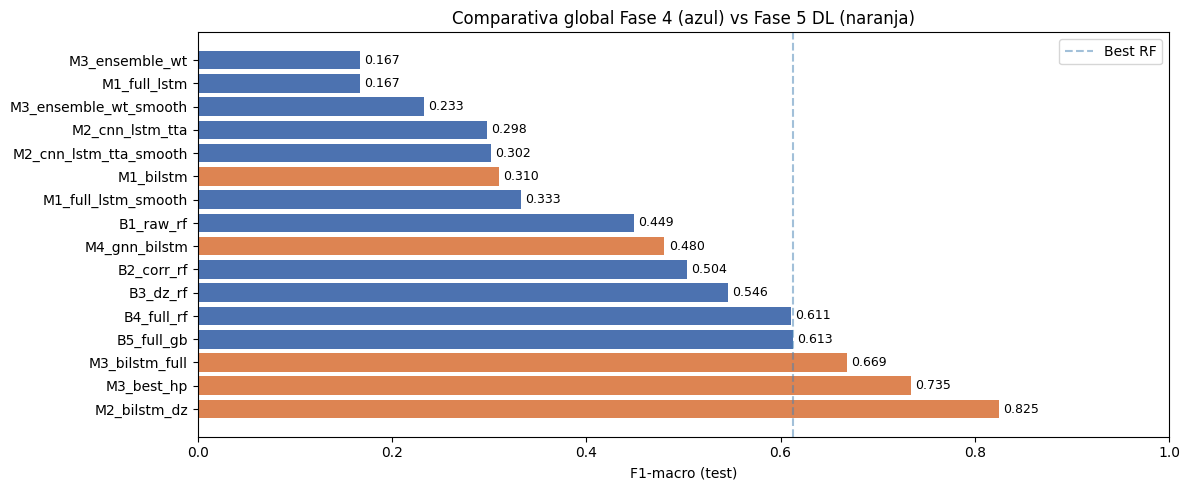

Guardado: results/phase5_comparison.png


In [21]:
# Comparative bar chart.
# NOTE: the rendered labels in this cell stay in Spanish on purpose. The figure
# is used by the dissertation, which is not distributed here.
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#4C72B0' if p == 4 else '#DD8452' for p in df_summary['phase']]
bars = ax.barh(df_summary['model'], df_summary['test_f1_macro'], color=colors)
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
ax.set_xlim(0, 1.0)
ax.set_xlabel('F1-macro (test)')
ax.set_title('Comparativa global Fase 4 (azul) vs Fase 5 DL (naranja)')
ax.axvline(df_summary.loc[df_summary['phase']==4, 'test_f1_macro'].max(),
           color='steelblue', linestyle='--', alpha=0.5, label='Best RF')
ax.legend()
plt.tight_layout()
# Figure text kept in Spanish: this PNG is included in the thesis.
plt.savefig('../results/phase5_comparison.png', dpi=150)
plt.show()
print('Saved: results/phase5_comparison.png')


## §14 Temporal cross-validation

A single video cannot support a real leave-one-lab-out, so this is the closest
available proxy: k-fold cross-validation over time, with no future data leaking into
a training fold.

It bounds generalisation within one recording, which is weaker than it sounds. §A1
is the real test.

In [22]:
from sklearn.model_selection import TimeSeriesSplit

K_FOLDS = 5
tscv = TimeSeriesSplit(n_splits=K_FOLDS)

fold_f1s = []
N_total = X_m3.shape[0]
all_indices = np.arange(N_total)

for fold, (tr_idx, te_idx) in enumerate(tscv.split(all_indices)):
    # split validation from train (last 15%)
    va_size = max(1, len(tr_idx) // 7)
    va_idx, tr_idx = tr_idx[-va_size:], tr_idx[:-va_size]

    dl_tr_f, dl_va_f, dl_te_f = make_loaders(X_m3, y, tr_idx, va_idx, te_idx, bs=32)

    m_fold = BehaviorLSTM(
        input_size=64,
        hidden_size=int(best.hidden_size),
        num_layers=int(best.n_layers),
        n_classes=N_CLASSES,
        dropout=float(best.dropout),
        bidirectional=True,
        use_attention=True,
    ).to(device)

    fit(
        m_fold, dl_tr_f, dl_va_f,
        epochs=60, lr=1e-3, weight_decay=1e-4, patience=10,
        device=device, augment=True, mixup_alpha=0.4, verbose=False,
    )

    m_fold.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in dl_te_f:
            xb = torch.nan_to_num(xb.to(device), nan=0.0)
            preds.extend(m_fold(xb).argmax(-1).cpu().numpy())
            trues.extend(yb.numpy())
    f1_fold = f1_score(trues, preds, average='macro', zero_division=0)
    fold_f1s.append(f1_fold)
    print(f'Fold {fold+1}/{K_FOLDS}  F1-macro={f1_fold:.3f}')

print(f'\nCV F1-macro: {np.mean(fold_f1s):.3f} ± {np.std(fold_f1s):.3f}')


Fold 1/5  F1-macro=0.128
Fold 2/5  F1-macro=0.127
Fold 3/5  F1-macro=0.238
Fold 4/5  F1-macro=0.393
Fold 5/5  F1-macro=0.509

CV F1-macro: 0.279 ± 0.151


## §15a M5: the 5-video dataset

> **Superseded by §A1.** §15a to §15g use the 5-video cache, which has only 3
> cross-video evaluable classes. They were how M5, M6 and the deep LOVO were
> developed. The reportable benchmark is **§A1**, over 20 videos and 5 evaluable
> classes. Do not compare these F1 values with those.

Loads `CalMS21_task1_multi_5_features.npz`: 1,781 windows, 7 classes, the same 64
features as M3.

In [23]:
# Load the multi-video NPZ
NPZ_PATH = '../dataset/features/CalMS21_task1_multi_5_features.npz'

_cache      = np.load(NPZ_PATH, allow_pickle=True)
X_multi     = _cache['X'].astype(np.float32)   # (1781, 64, 64)
y_multi     = _cache['y'].astype(np.int64)       # already int-encoded (0..N-1)
video_ids   = _cache['video_ids']               # per-window video ID
multi_cls   = list(_cache['classes'])

# LabelEncoder only needed for its .classes attribute (y is already encoded)
enc_multi       = LabelEncoder(classes=multi_cls, background_label='background')
N_CLASSES_MULTI = enc_multi.n_classes

print(f'X_multi: {X_multi.shape}')
print(f'Classes ({N_CLASSES_MULTI}): {multi_cls}')
print(f'Videos:  {np.unique(video_ids)}')

from collections import Counter as _Counter
print('\nWindows per video:')
for vid, cnt in sorted(_Counter(video_ids).items(), key=lambda x: -x[1]):
    print(f'  {vid}: {cnt}')
print('\nWindows per class:')
for idx, cnt in sorted(_Counter(y_multi.tolist()).items()):
    print(f'  {multi_cls[idx]:20s}: {cnt}')


X_multi: (1781, 64, 64)
Clases (7): [np.str_('approach'), np.str_('intromit'), np.str_('mount'), np.str_('sniff'), np.str_('sniffbody'), np.str_('sniffface'), np.str_('sniffgenital')]
Vídeos:  ['1296577409' '13638642' '537514760' '687327340' '867864385']

Ventanas por vídeo:
  867864385: 470
  537514760: 435
  687327340: 409
  1296577409: 364
  13638642: 103

Ventanas por clase:
  approach            : 16
  intromit            : 125
  mount               : 505
  sniff               : 935
  sniffbody           : 34
  sniffface           : 15
  sniffgenital        : 151


## §15b M6: training on 5 videos

The same hyperparameters as the best M3, trained over the 5 videos with a stratified
70/15/15 split, to see what more data does at fixed architecture.

In [24]:
from sklearn.model_selection import train_test_split as _tts

# Filtrar background
_bg   = y_multi >= 0
X_mv  = X_multi[_bg]
y_mv  = y_multi[_bg]

# Stratified 70/15/15
_all  = np.arange(len(y_mv))
_tmp, idx_te_mv = _tts(_all, test_size=0.15, stratify=y_mv, random_state=SEED)
idx_tr_mv, idx_va_mv = _tts(_tmp, test_size=0.15/0.85,
                             stratify=y_mv[_tmp], random_state=SEED)

dl_m5_tr, dl_m5_va, dl_m5_te = make_loaders(X_mv, y_mv,
                                              idx_tr_mv, idx_va_mv, idx_te_mv, bs=32)
print(f'Multi split → tr={len(idx_tr_mv)}, va={len(idx_va_mv)}, te={len(idx_te_mv)}')

Multi split → tr=1246, va=267, te=268


M5 params: 629,255
Epoch   1/100 | train_loss=1.4061  tr_f1=0.2015 | val_loss=0.9726  val_f1=0.2641 | lr=1.00e-03 | (4.4s) ★
Epoch   2/100 | train_loss=1.2082  tr_f1=0.2392 | val_loss=0.9602  val_f1=0.3705 | lr=9.99e-04 | (4.8s) ★
Epoch   3/100 | train_loss=1.1589  tr_f1=0.2058 | val_loss=0.8456  val_f1=0.4134 | lr=9.98e-04 | (5.2s) ★
Epoch   4/100 | train_loss=1.0979  tr_f1=0.3225 | val_loss=0.8185  val_f1=0.4055 | lr=9.96e-04 | (4.5s)
Epoch   5/100 | train_loss=1.0131  tr_f1=0.3033 | val_loss=0.8562  val_f1=0.3494 | lr=9.94e-04 | (4.2s)
Epoch   6/100 | train_loss=0.9842  tr_f1=0.2333 | val_loss=0.7439  val_f1=0.3221 | lr=9.91e-04 | (4.3s)
Epoch   7/100 | train_loss=0.9432  tr_f1=0.3315 | val_loss=0.7389  val_f1=0.4767 | lr=9.88e-04 | (4.2s) ★
Epoch   8/100 | train_loss=0.9316  tr_f1=0.3388 | val_loss=0.7170  val_f1=0.4699 | lr=9.84e-04 | (4.8s)
Epoch   9/100 | train_loss=0.9017  tr_f1=0.3003 | val_loss=0.7352  val_f1=0.3130 | lr=9.80e-04 | (4.3s)
Epoch  10/100 | train_loss=0.8858  tr

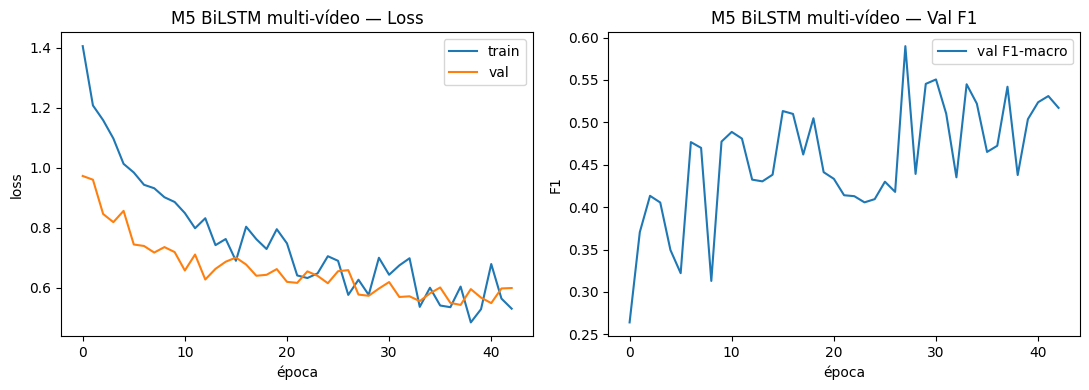

In [25]:
model_m5 = BehaviorLSTM(
    input_size=64, hidden_size=128, num_layers=2,
    n_classes=N_CLASSES_MULTI, dropout=0.3,
    bidirectional=True, use_attention=True,
).to(device)
print(f'M5 params: {sum(p.numel() for p in model_m5.parameters()):,}')

hist_m5 = fit(
    model_m5, dl_m5_tr, dl_m5_va,
    epochs=100, lr=1e-3, weight_decay=1e-4, patience=15,
    device=device, augment=True, mixup_alpha=0.4,
    checkpoint_path=f'{CHECKPOINT_DIR}/m5_multi_bilstm.pt',
    verbose=True,
)
plot_history(hist_m5, 'M5 BiLSTM, multi-video')


=== M5 — Test multi-vídeo ===
              precision    recall  f1-score   support

    approach       1.00      0.50      0.67         2
    intromit       0.92      0.58      0.71        19
       mount       0.80      0.87      0.84        76
       sniff       0.83      0.91      0.86       141
   sniffbody       0.33      0.20      0.25         5
   sniffface       0.00      0.00      0.00         2
sniffgenital       0.79      0.48      0.59        23

    accuracy                           0.81       268
   macro avg       0.67      0.50      0.56       268
weighted avg       0.81      0.81      0.80       268



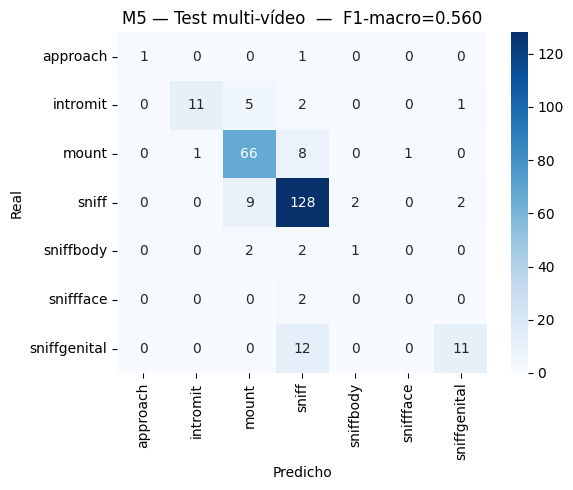

In [26]:
model_m5.load_state_dict(torch.load(
    f'{CHECKPOINT_DIR}/m5_multi_bilstm.pt', map_location=device, weights_only=True))
f1_m5 = evaluate_model(model_m5, dl_m5_te, enc_multi, device, 'M5 - multi-video test')

## §15c M7: leave-one-video-out over 5 videos

Trains on 4 videos and tests on the fifth, unseen, repeated for all 5. Reports mean
macro-F1 and standard deviation, and overwrites `results/lovo_results.csv`.

This is the first protocol in the project that measures generalisation rather than
fit, and the drop against the single-video numbers is the reason everything after it
exists.

In [27]:
video_ids_mv = video_ids[_bg]
unique_vids  = np.unique(video_ids_mv)
lovo_rows    = []

for test_vid in unique_vids:
    te_mask = video_ids_mv == test_vid
    tr_mask = ~te_mask

    X_ltr, y_ltr = X_mv[tr_mask], y_mv[tr_mask]
    X_lte, y_lte = X_mv[te_mask], y_mv[te_mask]

    # Val split from train (15%)
    _tr_all = np.arange(len(y_ltr))
    try:
        _tr_i, _va_i = _tts(_tr_all, test_size=0.15, stratify=y_ltr, random_state=SEED)
    except ValueError:
        _tr_i, _va_i = _tts(_tr_all, test_size=0.15, random_state=SEED)

    _dl_tr = DataLoader(MouseBehaviorDataset(X_ltr[_tr_i], y_ltr[_tr_i]),
                        batch_size=32, shuffle=True)
    _dl_va = DataLoader(MouseBehaviorDataset(X_ltr[_va_i], y_ltr[_va_i]), batch_size=32)
    _dl_te = DataLoader(MouseBehaviorDataset(X_lte, y_lte), batch_size=32)

    m_lovo = BehaviorLSTM(
        input_size=64, hidden_size=128, num_layers=2,
        n_classes=N_CLASSES_MULTI, dropout=0.3,
        bidirectional=True, use_attention=True,
    ).to(device)

    fit(m_lovo, _dl_tr, _dl_va,
        epochs=80, lr=1e-3, weight_decay=1e-4, patience=15,
        device=device, augment=True, mixup_alpha=0.4, verbose=False)

    m_lovo.eval()
    preds_lv, trues_lv = [], []
    with torch.no_grad():
        for xb, yb in _dl_te:
            xb = torch.nan_to_num(xb.to(device), nan=0.0)
            preds_lv.extend(m_lovo(xb).argmax(-1).cpu().numpy())
            trues_lv.extend(yb.numpy())

    f1_lv = f1_score(trues_lv, preds_lv, average='macro', zero_division=0)
    per_cls = f1_score(trues_lv, preds_lv, average=None, zero_division=0,
                       labels=list(range(N_CLASSES_MULTI)))
    row = {'test_video': test_vid, 'f1_macro': round(f1_lv, 4),
           'n_test': int(te_mask.sum())}
    for i, cls in enumerate(enc_multi.classes):
        row[f'f1_{cls}'] = round(float(per_cls[i]) if i < len(per_cls) else 0.0, 4)
    lovo_rows.append(row)
    print(f'LOVO {test_vid}: F1-macro={f1_lv:.3f}  (n_test={int(te_mask.sum())})')

df_lovo = pd.DataFrame(lovo_rows)
print(f'\nLOVO mean F1-macro: {df_lovo.f1_macro.mean():.3f} ± {df_lovo.f1_macro.std():.3f}')
df_lovo.to_csv('../results/lovo_results.csv', index=False)
print('Saved: results/lovo_results.csv')

LOVO 1296577409: F1-macro=0.172  (n_test=364)
LOVO 13638642: F1-macro=0.069  (n_test=103)
LOVO 537514760: F1-macro=0.205  (n_test=435)
LOVO 687327340: F1-macro=0.267  (n_test=409)
LOVO 867864385: F1-macro=0.266  (n_test=470)

LOVO mean F1-macro: 0.196 ± 0.082
Guardado: results/lovo_results.csv


## §15d M8: does a smaller model do better?

With a small dataset, capacity can hurt. Compares GRU-32, GRU-64 and BiLSTM-64x1
against the BiLSTM-128x2 of M5, all on the same split.

In [28]:
from src.models.rnn import BehaviorGRU

_size_cfgs = [
    ('GRU-32',      'gru',  32, 1),
    ('GRU-64',      'gru',  64, 1),
    ('BiLSTM-64x1', 'lstm', 64, 1),
]
size_results = []

for name, arch, hidden, layers in _size_cfgs:
    if arch == 'gru':
        _m = BehaviorGRU(input_size=64, hidden_size=hidden,
                         n_classes=N_CLASSES_MULTI, dropout=0.3).to(device)
    else:
        _m = BehaviorLSTM(input_size=64, hidden_size=hidden, num_layers=layers,
                          n_classes=N_CLASSES_MULTI, dropout=0.3,
                          bidirectional=True, use_attention=True).to(device)

    n_par = sum(p.numel() for p in _m.parameters())
    _ckpt = f'{CHECKPOINT_DIR}/m8_{name.lower()}.pt'

    fit(_m, dl_m5_tr, dl_m5_va,
        epochs=100, lr=1e-3, weight_decay=1e-4, patience=15,
        device=device, augment=True, mixup_alpha=0.4,
        checkpoint_path=_ckpt, verbose=False)

    _m.load_state_dict(torch.load(_ckpt, map_location=device, weights_only=True))
    _m.eval()
    _p, _t = [], []
    with torch.no_grad():
        for xb, yb in dl_m5_te:
            xb = torch.nan_to_num(xb.to(device), nan=0.0)
            _p.extend(_m(xb).argmax(-1).cpu().numpy())
            _t.extend(yb.numpy())
    _f1 = f1_score(_t, _p, average='macro', zero_division=0)
    size_results.append({'model': name, 'params': n_par, 'test_f1': round(_f1, 4)})
    print(f'{name:15s}  params={n_par:>8,}  F1={_f1:.3f}')

# Add M5 as reference
size_results.append({
    'model': 'BiLSTM-128x2 (M5)',
    'params': sum(p.numel() for p in model_m5.parameters()),
    'test_f1': round(f1_m5, 4),
})
df_sizes = pd.DataFrame(size_results).sort_values('test_f1', ascending=False)
print('\n', df_sizes.to_string(index=False))

GRU-32           params=  10,247  F1=0.426
GRU-64           params=  27,655  F1=0.459
BiLSTM-64x1      params=  76,039  F1=0.539

             model  params  test_f1
BiLSTM-128x2 (M5)  629255   0.5602
      BiLSTM-64x1   76039   0.5385
           GRU-64   27655   0.4587
           GRU-32   10247   0.4263


## §15e M9: handling class imbalance

`WeightedRandomSampler` oversamples the minority classes each epoch, combined with
`focal_gamma=3.0` to push the loss further away from easy examples. Compared against
M5, which is the same model with uniform sampling and gamma 2.0.

Epoch   1/100 | train_loss=0.9856  tr_f1=0.1315 | val_loss=0.0770  val_f1=0.0140 | lr=1.00e-03 | (4.7s) ★
Epoch   2/100 | train_loss=0.5372  tr_f1=0.1682 | val_loss=0.0722  val_f1=0.0459 | lr=9.99e-04 | (4.6s) ★
Epoch   3/100 | train_loss=0.4531  tr_f1=0.2014 | val_loss=0.0633  val_f1=0.0274 | lr=9.98e-04 | (4.4s)
Epoch   4/100 | train_loss=0.4270  tr_f1=0.2267 | val_loss=0.0534  val_f1=0.0505 | lr=9.96e-04 | (4.5s) ★
Epoch   5/100 | train_loss=0.4495  tr_f1=0.1731 | val_loss=0.0484  val_f1=0.1145 | lr=9.94e-04 | (4.3s) ★
Epoch   6/100 | train_loss=0.3069  tr_f1=0.1922 | val_loss=0.0582  val_f1=0.0622 | lr=9.91e-04 | (4.7s)
Epoch   7/100 | train_loss=0.3119  tr_f1=0.2440 | val_loss=0.0503  val_f1=0.0880 | lr=9.88e-04 | (4.6s)
Epoch   8/100 | train_loss=0.2483  tr_f1=0.2546 | val_loss=0.0585  val_f1=0.0605 | lr=9.84e-04 | (4.5s)
Epoch   9/100 | train_loss=0.2615  tr_f1=0.2460 | val_loss=0.0547  val_f1=0.0553 | lr=9.80e-04 | (4.4s)
Epoch  10/100 | train_loss=0.2106  tr_f1=0.2810 | val_lo

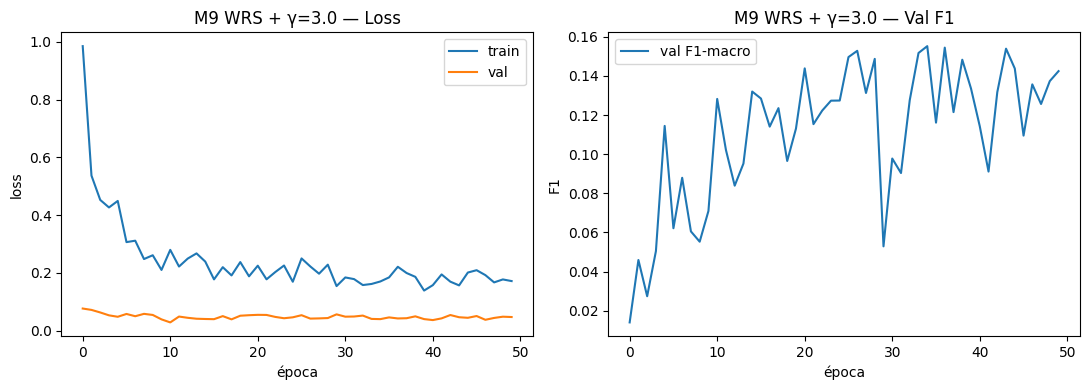

In [29]:
from src.data.dataset import make_weighted_sampler

_ds_tr    = MouseBehaviorDataset(X_mv[idx_tr_mv], y_mv[idx_tr_mv])
_sampler  = make_weighted_sampler(_ds_tr.y.numpy())
dl_m5_tr_wrs = DataLoader(_ds_tr, batch_size=32, sampler=_sampler, num_workers=0)

_cls_w       = _ds_tr.class_weights().to(device)
_crit_g3     = FocalLoss(gamma=3.0, weight=_cls_w)

model_m9 = BehaviorLSTM(
    input_size=64, hidden_size=128, num_layers=2,
    n_classes=N_CLASSES_MULTI, dropout=0.3,
    bidirectional=True, use_attention=True,
).to(device)

hist_m9 = fit(
    model_m9, dl_m5_tr_wrs, dl_m5_va,
    epochs=100, lr=1e-3, weight_decay=1e-4, patience=15,
    device=device, augment=True, mixup_alpha=0.4,
    criterion=_crit_g3,
    checkpoint_path=f'{CHECKPOINT_DIR}/m9_wrs_gamma3.pt',
    verbose=True,
)
plot_history(hist_m9, 'M9 WRS + γ=3.0')


=== M9 — WRS + γ=3.0 (Test multi-vídeo) ===
              precision    recall  f1-score   support

    approach       0.02      0.50      0.04         2
    intromit       0.56      0.26      0.36        19
       mount       0.00      0.00      0.00        76
       sniff       0.00      0.00      0.00       141
   sniffbody       0.02      0.20      0.04         5
   sniffface       0.01      0.50      0.01         2
sniffgenital       0.17      0.13      0.15        23

    accuracy                           0.04       268
   macro avg       0.11      0.23      0.09       268
weighted avg       0.05      0.04      0.04       268



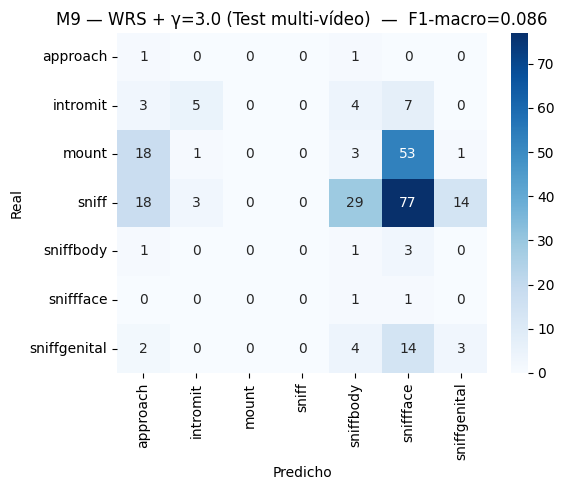

In [30]:
model_m9.load_state_dict(torch.load(
    f'{CHECKPOINT_DIR}/m9_wrs_gamma3.pt', map_location=device, weights_only=True))
f1_m9 = evaluate_model(model_m9, dl_m5_te, enc_multi, device,
                        'M9 - WRS + gamma=3.0 (multi-video test)')

## §15f M10: calibration

The expected calibration error measures the gap between a model's confidence and
its accuracy; zero means perfectly calibrated. Focal loss tends to produce
overconfidence, so M5 (gamma 2.0) and M9 (gamma 3.0 plus weighted sampling) are
compared and their reliability diagrams plotted.

ECE M5  (γ=2.0, uniform): 0.0597
ECE M9  (γ=3.0, WRS):     0.4230


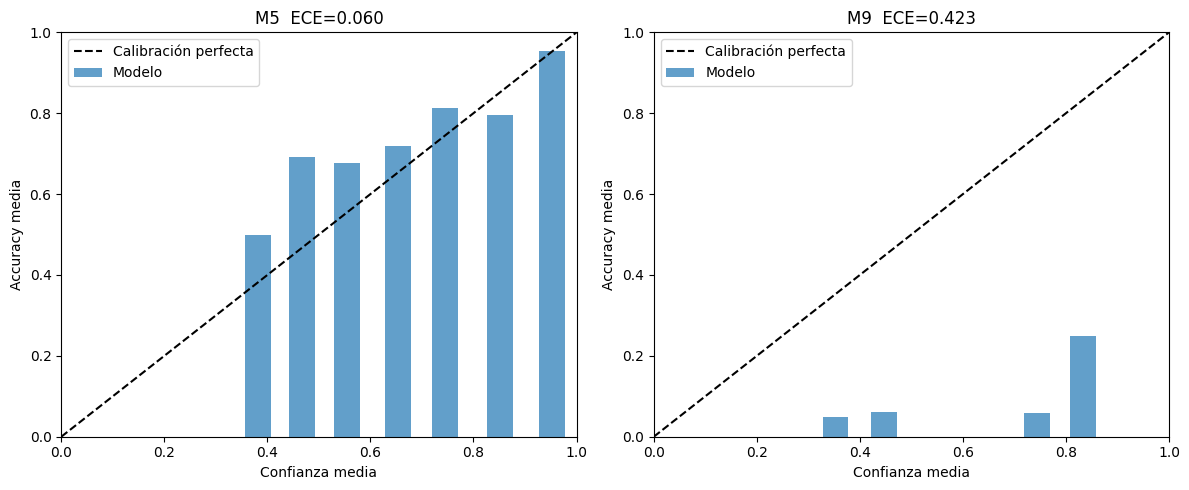

In [31]:
import torch.nn.functional as F
from src.evaluate import expected_calibration_error

def _collect_probs(model, loader, device):
    model.eval()
    all_probs, all_true = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = torch.nan_to_num(xb.to(device), nan=0.0)
            probs = F.softmax(model(xb), dim=-1).cpu().numpy()
            all_probs.append(probs)
            all_true.append(yb.numpy())
    return np.concatenate(all_probs), np.concatenate(all_true)

probs_m5, true_m5 = _collect_probs(model_m5, dl_m5_te, device)
probs_m9, true_m9 = _collect_probs(model_m9, dl_m5_te, device)

ece_m5, bc5, ba5, _ = expected_calibration_error(true_m5, probs_m5)
ece_m9, bc9, ba9, _ = expected_calibration_error(true_m9, probs_m9)

print(f'ECE M5  (γ=2.0, uniform): {ece_m5:.4f}')
print(f'ECE M9  (γ=3.0, WRS):     {ece_m9:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, bc, ba, ece, title in [
    (axes[0], bc5, ba5, ece_m5, f'M5  ECE={ece_m5:.3f}'),
    (axes[1], bc9, ba9, ece_m9, f'M9  ECE={ece_m9:.3f}'),
]:
    ax.bar(bc, ba, width=0.05, alpha=0.7, label='Model')
    ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
    ax.set(xlabel='Confianza media', ylabel='Accuracy media',
           title=title, xlim=(0, 1), ylim=(0, 1))
    ax.legend()
plt.tight_layout()
plt.savefig('../results/reliability_diagrams.png', dpi=150)
plt.show()

## §15g Global summary table

> **Mixed protocols: single-video and 5-video rows together.** Not comparable across
> rows. The honest headline is §A1, over 20 videos. Kept as a record.

                 model  phase n_features  test_f1_macro
          M2_bilstm_dz      5         51         0.8252
            M3_best_hp      5         64         0.7348
        M3_bilstm_full      5         64         0.6689
            B5_full_gb      4        576         0.6130
            B4_full_rf      4        576         0.6110
  M5_multi_bilstm128x2      6         64         0.5602
  M8_BiLSTM-128x2 (M5)      6         64         0.5602
              B3_dz_rf      4        459         0.5460
        M8_BiLSTM-64x1      6         64         0.5385
            B2_corr_rf      4        387         0.5040
         M4_gnn_bilstm      5       7n×5         0.4805
             M8_GRU-64      6         64         0.4587
             B1_raw_rf      4        387         0.4490
             M8_GRU-32      6         64         0.4263
   M1_full_lstm_smooth      4         64         0.3330
             M1_bilstm      5         43         0.3105
M2_cnn_lstm_tta_smooth      4         64        

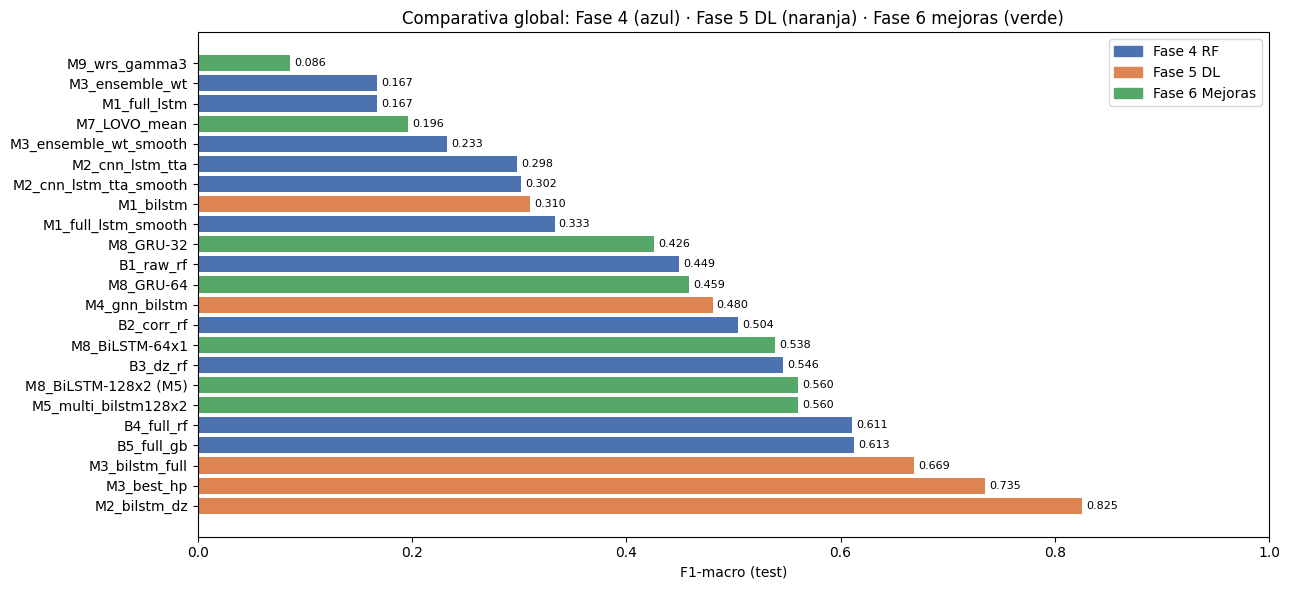

In [32]:
df_ph5 = pd.read_csv('../results/phase5_summary.csv')

_new = []
for _model, _f1 in [
    ('M5_multi_bilstm128x2', f1_m5),
    ('M9_wrs_gamma3',        f1_m9),
]:
    _new.append({'model': _model, 'phase': 6, 'n_features': 64,
                 'test_f1_macro': round(_f1, 4)})

# Size ablation rows
for _, _r in df_sizes.iterrows():
    _new.append({'model': f'M8_{_r.model}', 'phase': 6, 'n_features': 64,
                 'test_f1_macro': _r.test_f1})

# LOVO mean row
_new.append({'model': 'M7_LOVO_mean', 'phase': 6, 'n_features': 64,
             'test_f1_macro': round(df_lovo.f1_macro.mean(), 4)})

df_all = pd.concat([df_ph5, pd.DataFrame(_new)], ignore_index=True)
df_all = df_all.drop_duplicates(subset='model', keep='last')
df_all = df_all.sort_values('test_f1_macro', ascending=False).reset_index(drop=True)
print(df_all.to_string(index=False))
df_all.to_csv('../results/phase5_summary.csv', index=False)
print('\nActualizado: results/phase5_summary.csv')

# Bar chart
fig, ax = plt.subplots(figsize=(13, 6))
_colors = ['#4C72B0' if p == 4 else ('#DD8452' if p == 5 else '#55A868')
           for p in df_all['phase']]
_bars = ax.barh(df_all['model'], df_all['test_f1_macro'], color=_colors)
ax.bar_label(_bars, fmt='%.3f', padding=3, fontsize=8)
ax.set_xlim(0, 1.0)
ax.set_xlabel('F1-macro (test)')
ax.set_title('Comparativa global: Fase 4 (azul) · Fase 5 DL (naranja) · Fase 6 mejoras (verde)')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#4C72B0', label='Fase 4 RF'),
                   Patch(color='#DD8452', label='Fase 5 DL'),
                   Patch(color='#55A868', label='Fase 6 Mejoras')])
plt.tight_layout()
# Figure text kept in Spanish: this PNG is included in the thesis.
plt.savefig('../results/phase6_comparison.png', dpi=150)
plt.show()

## §15 Conclusions from the single-video and 5-video phase

**Written before the honest evaluation. Two of these did not survive it**, and the
corrected versions are in §A1, §A4 and notebook 04. Kept because the sequence is
part of the result.

### Feature ablation, M1 to M3

The measured values are M1 0.311, M2 0.825, M3 0.669, and the best M3 after
hyperparameter search 0.735.

The largest single jump is **M1 to M2**, that is, adding Δz. That is the opposite of
what the original conclusion said, which credited the relational features. M3 scores
*below* M2 despite having strictly more information, which on 32 test windows is
what an unstable estimate looks like rather than evidence that relational features
hurt.

The honest reading is that this phase cannot order the feature blocks. What it can
say, and what §A1 confirms, is that feature engineering beats raw signal.

### M4, the graph model

The skeleton graph gives an explicit spatial inductive bias: adjacent keypoints are
edges rather than correlations the LSTM has to discover. It scores 0.481, below the
vector BiLSTM, which is consistent with 877,253 parameters over roughly 208 training
windows. It would need more data to be worth its size, not a better architecture.

### Limitations

One laboratory, so the temporal cross-validation has high variance. The natural
extension is a real leave-one-lab-out, which notebook 07 eventually does over nine
laboratories. M4 could also gain inter-mouse edges, putting the interaction in the
graph instead of in concatenated embeddings.

## §16 Skeleton correction ablation on the BiLSTM (single video)

> **Within-video result, high variance. This is NOT the verdict.** Trained and
> evaluated on one video with a temporal split and a few dozen test windows. Here
> the correction *appears to help* (Raw-43 to Corr-43 is positive) and **that does
> not generalise**: the reportable result is the cross-video comparison in **§A4**,
> 20 paired LOVO folds, where the correction is neutral to negative and
> significantly harmful on `f1_event`.
>
> The discrepancy is expected rather than puzzling. The correction is fitted per
> video and smooths trajectories in a way that flatters a within-video split but does
> not transfer to unseen videos.

Three conditions, same model and same hyperparameters:

| Config | Tracking | Features | What it isolates |
|--------|----------|----------|------------------|
| **Raw-43** | uncorrected | 43 | baseline |
| **Corr-43** | MouseSkeleton | 43 | the correction on its own |
| **Corr-64** | MouseSkeleton | 64 | plus Δz and relational (= best M3) |

In [33]:
# Extract RAW features, with no skeletal correction
import sys
sys.path.insert(0, '..')
from src.data.loader import load_tracking, load_annotations
from src.skeleton import build_skeleton, fit_skeleton
from src.data.features import extract_features

VIDEO_ID = '13638642'
LAB_ID   = 'CalMS21_task1'

# RAW tracking: smooth_video is NOT called
tracking_raw = load_tracking(VIDEO_ID, LAB_ID)
ann_df_abl   = load_annotations(VIDEO_ID, LAB_ID)

# Skeleton fitted to the raw video, needed only for L_body_median_px
skeleton_raw = build_skeleton(LAB_ID)
skeleton_raw = fit_skeleton(skeleton_raw, tracking_raw)
print(f'L_body_median_px (raw) = {skeleton_raw.L_body_median_px:.1f} px')

# The 43 kinematic features, over uncorrected tracking
res_raw = extract_features(
    tracking_raw, skeleton_raw, ann_df_abl,
    include_dz=False,
    include_relational=False,
)
X_raw43_all = res_raw[1]['X'].astype(np.float32)
y_raw_str   = res_raw[1]['y']
print(f'RAW features : {X_raw43_all.shape}  (expected: N x 64 x 43)')
print(f'Label counts : {dict(zip(*np.unique(y_raw_str, return_counts=True)))}')

L_body_median_px (raw) = 175.5 px
Features RAW : (179, 64, 43)  (esperado: N x 64 x 43)
Label counts : {'approach': np.int64(16), 'background': np.int64(76), 'mount': np.int64(21), 'sniffbody': np.int64(34), 'sniffface': np.int64(15), 'sniffgenital': np.int64(17)}


In [34]:
# Label encoding and a proportional temporal split
y_raw  = enc.encode(list(y_raw_str))
n_raw  = len(y_raw)
n_corr = len(y)
print(f'RAW windows: {n_raw}  |  CORR windows: {n_corr}')

# Keep the same split proportions as the corrected pipeline
_tr_frac = len(idx_tr) / n_corr
_va_frac = len(idx_va) / n_corr
_tr_end  = int(n_raw * _tr_frac)
_va_end  = int(n_raw * (_tr_frac + _va_frac))
idx_tr_raw = np.arange(0,       _tr_end)
idx_va_raw = np.arange(_tr_end, _va_end)
idx_te_raw = np.arange(_va_end, n_raw)
print(f'Split raw  -> tr={len(idx_tr_raw)}, va={len(idx_va_raw)}, te={len(idx_te_raw)}')
print(f'Split corr -> tr={len(idx_tr)},     va={len(idx_va)},     te={len(idx_te)}')

# DataLoaders
dl_raw43_tr, dl_raw43_va, dl_raw43_te = make_loaders(
    X_raw43_all, y_raw, idx_tr_raw, idx_va_raw, idx_te_raw)
# Corr-43 reuses X_m1, corrected[:, :, :43], with the original split
dl_corr43_tr, dl_corr43_va, dl_corr43_te = make_loaders(
    X_m1, y, idx_tr, idx_va, idx_te)
print('DataLoaders OK')

Ventanas RAW: 179  |  Ventanas CORR: 357
Split raw  → tr=124, va=27, te=28
Split corr → tr=249,     va=54,     te=54
DataLoaders OK


Params: 607,237

=== Raw-43 — sin MouseSkeleton ===
              precision    recall  f1-score   support

    approach       0.00      0.00      0.00         3
       mount       1.00      0.33      0.50         3
   sniffbody       0.00      0.00      0.00         0
   sniffface       0.00      0.00      0.00         2
sniffgenital       0.00      0.00      0.00         0

    accuracy                           0.12         8
   macro avg       0.20      0.07      0.10         8
weighted avg       0.38      0.12      0.19         8



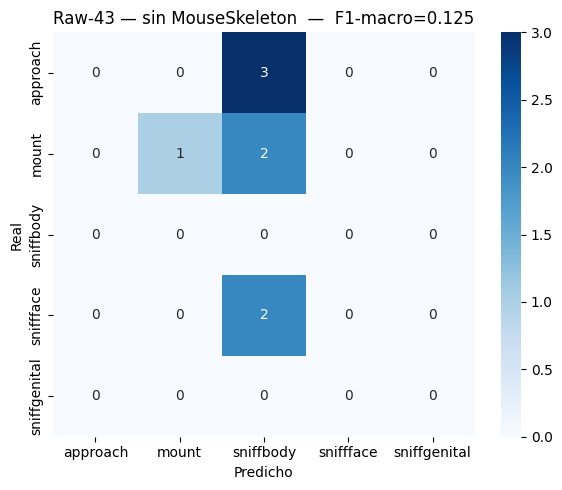


F1 Raw-43 = 0.1250


In [35]:
# BiLSTM Raw-43: uncorrected tracking, 43 features
torch.manual_seed(SEED)
model_abl_raw43 = BehaviorLSTM(
    input_size=43, hidden_size=128, num_layers=2,
    n_classes=N_CLASSES, dropout=0.3,
    bidirectional=True, use_attention=True,
).to(device)
print(f'Params: {sum(p.numel() for p in model_abl_raw43.parameters()):,}')

fit(
    model_abl_raw43, dl_raw43_tr, dl_raw43_va,
    epochs=80, lr=1e-3, weight_decay=1e-4, patience=15,
    device=device, augment=True, mixup_alpha=0.4,
    checkpoint_path=f'{CHECKPOINT_DIR}/m_abl_raw43.pt',
    verbose=False,
)
model_abl_raw43.load_state_dict(torch.load(
    f'{CHECKPOINT_DIR}/m_abl_raw43.pt', map_location=device, weights_only=True))
f1_abl_raw43 = evaluate_model(
    model_abl_raw43, dl_raw43_te, enc, device, 'Raw-43 - without MouseSkeleton')
print(f'\nF1 Raw-43 = {f1_abl_raw43:.4f}')

Params: 607,237

=== Corr-43 — MouseSkeleton, sin Δz/relacionales ===
              precision    recall  f1-score   support

    approach       0.00      0.00      0.00         5
       mount       0.50      0.83      0.62         6
   sniffbody       0.53      0.91      0.67        11
   sniffface       0.00      0.00      0.00         5
sniffgenital       0.33      0.20      0.25         5

    accuracy                           0.50        32
   macro avg       0.27      0.39      0.31        32
weighted avg       0.33      0.50      0.39        32



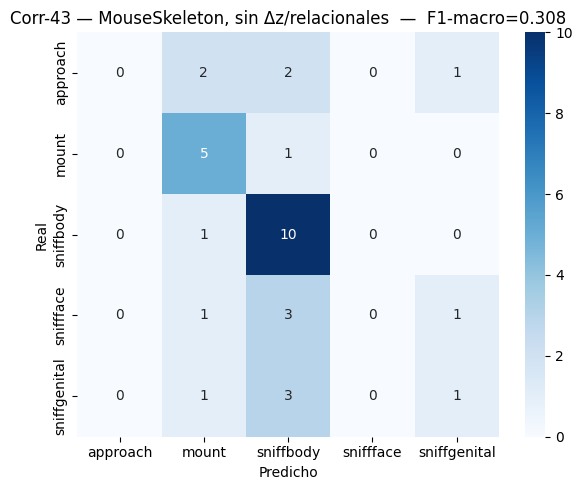


F1 Corr-43 = 0.3083


In [36]:
# BiLSTM Corr-43: corrected tracking, same 43 features, same model
torch.manual_seed(SEED)
model_abl_corr43 = BehaviorLSTM(
    input_size=43, hidden_size=128, num_layers=2,
    n_classes=N_CLASSES, dropout=0.3,
    bidirectional=True, use_attention=True,
).to(device)
print(f'Params: {sum(p.numel() for p in model_abl_corr43.parameters()):,}')

fit(
    model_abl_corr43, dl_corr43_tr, dl_corr43_va,
    epochs=80, lr=1e-3, weight_decay=1e-4, patience=15,
    device=device, augment=True, mixup_alpha=0.4,
    checkpoint_path=f'{CHECKPOINT_DIR}/m_abl_corr43.pt',
    verbose=False,
)
model_abl_corr43.load_state_dict(torch.load(
    f'{CHECKPOINT_DIR}/m_abl_corr43.pt', map_location=device, weights_only=True))
f1_abl_corr43 = evaluate_model(
    model_abl_corr43, dl_corr43_te, enc, device,
    'Corr-43 - MouseSkeleton, without dz or relational features')
print(f'\nF1 Corr-43 = {f1_abl_corr43:.4f}')


=== Corr-64 — M3_best_hp (+Δz +relacionales) ===
              precision    recall  f1-score   support

    approach       0.71      1.00      0.83         5
       mount       0.71      0.83      0.77         6
   sniffbody       0.69      0.82      0.75        11
   sniffface       1.00      0.40      0.57         5
sniffgenital       1.00      0.60      0.75         5

    accuracy                           0.75        32
   macro avg       0.82      0.73      0.73        32
weighted avg       0.80      0.75      0.74        32



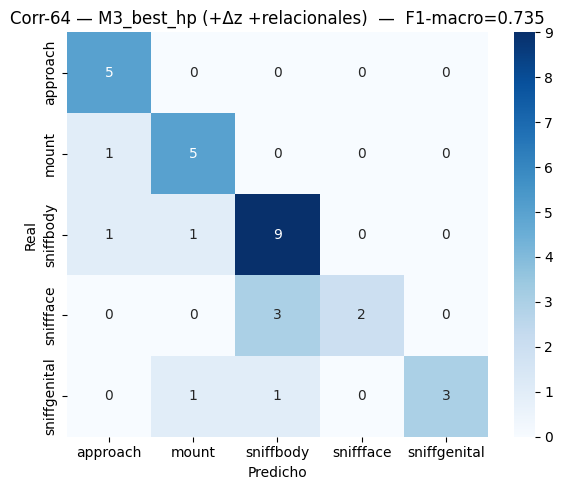


=== Ablación MouseSkeleton → BiLSTM ===
                  Condición  Tracking  N_feat  F1_macro
Raw-43  (sin MouseSkeleton)     crudo      43    0.1250
   Corr-43 (+MouseSkeleton) corregido      43    0.3083
Corr-64 (+Δz +relacionales) corregido      64    0.7348

  Δ corrección (Raw-43  → Corr-43):  +0.1833
  Δ features  (Corr-43 → Corr-64):  +0.4265
  Δ total     (Raw-43  → Corr-64):  +0.6098


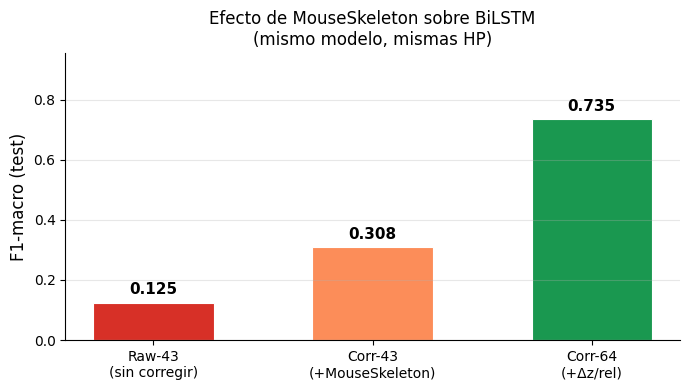

Guardado: results/skeleton_ablation.png
Actualizado: results/phase5_summary.csv


In [37]:
# Corr-64 is M3_best_hp, already trained above.
# NOTE: the chart's title and x-tick labels below stay in Spanish on purpose.
# The figure is used by the dissertation, which is not distributed here.
# Reusar la arquitectura ganadora de la busqueda de HP (§12): el checkpoint
# m3_best_calms21.pt was saved with those hyperparameters (n_layers=1 among
# them), so hard-coding num_layers=2 here broke load_state_dict on missing keys.
model_corr64 = BehaviorLSTM(
    input_size=64, hidden_size=int(best.hidden_size), num_layers=int(best.n_layers),
    n_classes=N_CLASSES, dropout=float(best.dropout),
    bidirectional=True, use_attention=True,
).to(device)
model_corr64.load_state_dict(torch.load(
    f'{CHECKPOINT_DIR}/m3_best_calms21.pt', map_location=device, weights_only=True))
f1_corr64 = evaluate_model(
    model_corr64, dl_m3_te, enc, device, 'Corr-64 — M3_best_hp (+Δz +relacionales)')

# ── Tabla comparativa ─────────────────────────────────────────────────
df_abl = pd.DataFrame([
    {'Condition': 'Raw-43  (no MouseSkeleton)',
     'Tracking': 'crudo',     'N_feat': 43, 'F1_macro': round(f1_abl_raw43,  4)},
    {'Condition': 'Corr-43 (+MouseSkeleton)',
     'Tracking': 'corregido', 'N_feat': 43, 'F1_macro': round(f1_abl_corr43, 4)},
    {'Condition': 'Corr-64 (+dz +relational)',
     'Tracking': 'corregido', 'N_feat': 64, 'F1_macro': round(f1_corr64,     4)},
])
print('\n=== MouseSkeleton ablation -> BiLSTM ===')
print(df_abl.to_string(index=False))
d_corr  = f1_abl_corr43 - f1_abl_raw43
d_feats = f1_corr64     - f1_abl_corr43
d_total = f1_corr64     - f1_abl_raw43
print(f'\n  delta from the correction (Raw-43 -> Corr-43):  {d_corr:+.4f}')
print(f'  Δ features  (Corr-43 → Corr-64):  {d_feats:+.4f}')
print(f'  Δ total     (Raw-43  → Corr-64):  {d_total:+.4f}')

# ── Chart ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
labels_abl = ['Raw-43\n(sin corregir)', 'Corr-43\n(+MouseSkeleton)', 'Corr-64\n(+Δz/rel)']
vals_abl   = [f1_abl_raw43, f1_abl_corr43, f1_corr64]
colors_abl = ['#d73027', '#fc8d59', '#1a9850']
bars = ax.bar(labels_abl, vals_abl, color=colors_abl,
              edgecolor='white', linewidth=0.8, width=0.55)
ax.bar_label(bars, fmt='%.3f', padding=4, fontsize=11, fontweight='bold')
ax.set_ylim(0, min(1.0, max(vals_abl) * 1.30))
ax.set_ylabel('F1-macro (test)', fontsize=12)
ax.set_title('Efecto de MouseSkeleton sobre BiLSTM\n(mismo modelo, mismas HP)',
             fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
# Figure text kept in Spanish: this PNG is included in the thesis.
plt.savefig('../results/skeleton_ablation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/skeleton_ablation.png')

# ── Actualizar phase5_summary.csv ────────────────────────────────────
_ph5 = pd.read_csv('../results/phase5_summary.csv')
_new = pd.DataFrame([
    {'model': 'M_abl_raw43',  'phase': 16, 'n_features': 43,
     'test_f1_macro': round(f1_abl_raw43,  4)},
    {'model': 'M_abl_corr43', 'phase': 16, 'n_features': 43,
     'test_f1_macro': round(f1_abl_corr43, 4)},
])
_ph5_upd = pd.concat([_ph5, _new], ignore_index=True)
_ph5_upd = _ph5_upd.drop_duplicates(subset='model', keep='last')
_ph5_upd.to_csv('../results/phase5_summary.csv', index=False)
print('Actualizado: results/phase5_summary.csv')

## §A1 Honest LOVO benchmark: deep models, 20 videos, raw tracking

The same sequence models under **leave-one-video-out** over the 20-video cache
(7,134 windows, 5 evaluable classes), with the identical protocol used in notebook
04 §A1: per-fold scaling on train, a stratified validation set from 15% of the
training videos, weighted cross entropy, and the official `f1_event`.

**The headline uses raw tracking**, following the verdict in §A4.

**Runtime.** 20 folds times models times epochs is expensive, so the notebook
restricts to `MODELS=[bilstm, tcn]` and `EPOCHS=15`. Raise both for more fidelity.

The expected result is that the models tie at 0.53 to 0.58 and are statistically
indistinguishable. "The random forest beats the BiLSTM" was an artefact of comparing
two different protocols.

In [38]:
import sys, pathlib
_r = pathlib.Path.cwd()
while _r != _r.parent and not (_r/'src').exists(): _r = _r.parent
sys.path.insert(0, str(_r)) if str(_r) not in sys.path else None

import numpy as np, pandas as pd
from sklearn.model_selection import LeaveOneGroupOut
from src.evaluation.lovo import (
    load_event_cache, evaluable_class_ids, fold_metrics, run_seq, event_f1_for_fold)

# Honest 20-video protocol. The headline figure uses RAW tracking, and reports the
# OFFICIAL MABe metric (f1_event) alongside the per-window F1. Runtime is
# 20 folds x model x EPOCHS, so to keep it tractable this is cut to 2 models
# (bilstm, tcn) at EPOCHS=15; the 20-video harness used epochs=12. Raise
# MODELS/EPOCHS for more fidelity, and quote the raw figure as the reportable one.
FEAT   = _r / "dataset" / "features"
CACHE  = FEAT / "CalMS21_task1_multi_20_event_raw.npz"   # raw, 20 videos
MODELS = ["bilstm", "tcn"]
EPOCHS = 15
X, y, vids, classes, ev = load_event_cache(CACHE)
nC = len(classes); eids = evaluable_class_ids(y, vids, classes)
print(f"Cache: {CACHE.name} | windows={len(X)} videos={len(set(vids))} "
      f"evaluable classes={len(eids)} {[classes[c] for c in eids]}")
if ev is None:
    print("⚠ event cache has no per-window metadata; run the cache-building cell in 03_features")

RESULTS_DIR = globals().get("RESULTS_DIR", _r / "results")
LAB = "CalMS21_task1"
rows = []
for name in MODELS:
    for fi, (tr, te) in enumerate(LeaveOneGroupOut().split(X, y, groups=vids)):
        pred, _ = run_seq(name, X[tr], y[tr], X[te], nC, epochs=EPOCHS)
        _, _, fe, ff = fold_metrics(y[te], pred, nC, eids)
        row = {"model": name, "fold": fi, "test_video": vids[te][0],
               "f1_eval": round(fe, 4), "f1_full": round(ff, 4)}
        fev = float("nan")
        if ev is not None:
            fev = event_f1_for_fold(LAB, vids[te][0], te, pred, classes, vids, ev)
            row["f1_event"] = round(fev, 4) if not np.isnan(fev) else np.nan
        _ev = f" f1_event={fev:.3f}" if not np.isnan(fev) else ""
        print(f"  {name:9s} fold{fi:<2d} {vids[te][0]:>10s}  f1_eval={fe:.3f}{_ev}")
        rows.append(row)
df_lovo_deep = pd.DataFrame(rows)
_cols = ["f1_eval", "f1_full"] + (["f1_event"] if "f1_event" in df_lovo_deep else [])
_summary = df_lovo_deep.groupby("model")[_cols].agg(["mean", "std"]).round(4)
print(_summary.to_string())
df_lovo_deep.to_csv(RESULTS_DIR / "lovo_deep_event.csv", index=False)
print("Saved:", RESULTS_DIR / "lovo_deep_event.csv")
_summary

Caché: CalMS21_task1_multi_20_event_raw.npz | ventanas=7134 vídeos=20 clases evaluables=5 ['attack', 'mount', 'sniff', 'sniffface', 'sniffgenital']
  bilstm    fold0  1185502231  f1_eval=0.647 f1_event=0.526
  bilstm    fold1  1296577409  f1_eval=0.506 f1_event=0.320
  bilstm    fold2  1495692909  f1_eval=0.737 f1_event=0.579
  bilstm    fold3  1522870122  f1_eval=0.659 f1_event=0.571
  bilstm    fold4  1682584277  f1_eval=0.574 f1_event=0.539
  bilstm    fold5   169344990  f1_eval=0.694 f1_event=0.594
  bilstm    fold6  1733083885  f1_eval=0.711 f1_event=0.609
  bilstm    fold7  1767632325  f1_eval=0.441 f1_event=0.407
  bilstm    fold8  1817903677  f1_eval=0.363 f1_event=0.209
  bilstm    fold9  1842114740  f1_eval=0.730 f1_event=0.604
  bilstm    fold10 2097395874  f1_eval=0.915 f1_event=0.600
  bilstm    fold11  464367887  f1_eval=0.881 f1_event=0.690
  bilstm    fold12  470631683  f1_eval=0.784 f1_event=0.620
  bilstm    fold13  537514760  f1_eval=0.742 f1_event=0.665
  bilstm    

f1_eval         f1_full         f1_event        
          mean     std    mean     std     mean     std
model                                                  
bilstm  0.7157  0.1523  0.3614  0.1444   0.5770  0.1429
tcn     0.7057  0.1435  0.3578  0.1564   0.5623  0.1291

## §A4 Does the correction help? BiLSTM, paired LOVO, 20 videos

The deep version of §A3 in notebook 04: the same honest LOVO protocol as §A1, with
the notebook's BiLSTM trained on **corrected** and on **raw** features, from paired
20-video caches identical except for `smooth_video`.

With 20 folds the paired delta has real power, and it reproduces the harness
verdict: window-F1 -0.028, p = 0.03. The correction is neutral to negative across
videos.

This is the section that **contradicts and corrects** the single-video ablation in
§16. The difference is not noise in one of them: §16 measures whether the correction
fits one video, §A4 measures whether it generalises, and those are different
questions with different answers.

In [39]:
# ── Effect of the MouseSkeleton correction (BiLSTM, paired LOVO) ─────────────
import sys, pathlib
_r = pathlib.Path.cwd()
while _r != _r.parent and not (_r/'src').exists(): _r = _r.parent
sys.path.insert(0, str(_r)) if str(_r) not in sys.path else None

import numpy as np, pandas as pd
from sklearn.model_selection import LeaveOneGroupOut
from src.evaluation.lovo import (
    load_event_cache, evaluable_class_ids, fold_metrics, run_seq, event_f1_for_fold)
from src.skeleton.metrics import bootstrap_ci, paired_wilcoxon

RESULTS_DIR = globals().get("RESULTS_DIR", _r / "results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
LAB  = "CalMS21_task1"
FEAT = _r / "dataset" / "features"
CACHES = {"corrected": FEAT / "CalMS21_task1_multi_20_event.npz",
          "raw":       FEAT / "CalMS21_task1_multi_20_event_raw.npz"}
SEQ_MODEL = "bilstm"   # this notebook's headline model
EPOCHS    = 20         # 20 folds x 2 variants = 40 training runs; raise for more fidelity

for _tag, _p in CACHES.items():
    if not _p.exists():
        raise FileNotFoundError(
            f"Cache {_tag} is missing: {_p.name}. Build the raw one with:\n"
            "  the cache-building cell in 03_features (RECOMPUTE=True) "
            "--out dataset/features/CalMS21_task1_multi_20_event_raw.npz")

def _lovo_seq(cache_path, tag):
    """BiLSTM under LOVO over one cache -> one row per video, same protocol as above."""
    X, y, vids, classes, ev = load_event_cache(cache_path)
    nC = len(classes); eids = evaluable_class_ids(y, vids, classes)
    rows = []
    for fi, (tr, te) in enumerate(LeaveOneGroupOut().split(X, y, groups=vids)):
        pred, _ = run_seq(SEQ_MODEL, X[tr], y[tr], X[te], nC, epochs=EPOCHS)
        _, _, fe, ff = fold_metrics(y[te], pred, nC, eids)
        row = {"model": SEQ_MODEL, "test_video": vids[te][0],
               "f1_eval": round(fe, 4), "f1_full": round(ff, 4)}
        if ev is not None:
            fev = event_f1_for_fold(LAB, vids[te][0], te, pred, classes, vids, ev)
            row["f1_event"] = round(fev, 4) if not np.isnan(fev) else np.nan
        rows.append(row)
        print(f"  [{tag:9s}] fold{fi} {vids[te][0]:>10s}  f1_eval={fe:.3f}")
    return pd.DataFrame(rows)

print(f"=== BiLSTM LOVO - corrected vs raw (EPOCHS={EPOCHS}) ===")
df_corr_seq = _lovo_seq(CACHES["corrected"], "corrected")
df_raw_seq  = _lovo_seq(CACHES["raw"], "raw")

_metrics = [m for m in ("f1_eval", "f1_full", "f1_event") if m in df_corr_seq.columns]
_agg = (df_corr_seq.groupby("model")[_metrics].mean().round(4)
        .join(df_raw_seq.groupby("model")[_metrics].mean().round(4),
              lsuffix="_corr", rsuffix="_raw"))
print("\n=== Mean over folds (corrected vs raw) ===")
print(_agg.to_string())

# Paired delta (corrected minus raw), per video
_KEY = ["model", "test_video"]
_verdict = []
for metric in _metrics:
    m = (df_raw_seq[_KEY + [metric]].merge(df_corr_seq[_KEY + [metric]], on=_KEY,
                                           suffixes=("_raw", "_corr"))
         .dropna(subset=[f"{metric}_raw", f"{metric}_corr"]))
    if len(m) < 3:
        continue
    raw_v = m[f"{metric}_raw"].to_numpy(); corr_v = m[f"{metric}_corr"].to_numpy()
    delta = corr_v - raw_v
    lo, hi = bootstrap_ci(delta, statistic="mean")
    wil = paired_wilcoxon(raw_v, corr_v)
    _verdict.append({
        "metric": metric, "n_pairs": len(m),
        "raw_mean": round(float(raw_v.mean()), 4),
        "corr_mean": round(float(corr_v.mean()), 4),
        "delta_mean": round(float(delta.mean()), 4),
        "ci_lo": round(float(lo), 4), "ci_hi": round(float(hi), 4),
        "wilcoxon_p": round(float(wil["p_value"]), 4),
        "helps": bool(delta.mean() > 0 and (lo > 0 or hi < 0) and wil["significant"]),
    })
df_skeleton_effect_seq = pd.DataFrame(_verdict)
print("\n=== MouseSkeleton effect (corrected minus raw), BiLSTM ===")
print(df_skeleton_effect_seq.to_string(index=False))
df_skeleton_effect_seq.to_csv(RESULTS_DIR / "skeleton_effect_deep.csv", index=False)
print("\nSaved:", RESULTS_DIR / "skeleton_effect_deep.csv")
print("Note: n=20 pairs (20 folds) gives real statistical power, and reproduces the "
      "harness verdict (bilstm window-F1 -0.028, p=0.03). Contrast with the "
      "single-video ablation above, which disagrees.")

=== BiLSTM LOVO — corregido vs crudo (EPOCHS=20) ===
  [corrected] fold0 1185502231  f1_eval=0.720
  [corrected] fold1 1296577409  f1_eval=0.521
  [corrected] fold2 1495692909  f1_eval=0.705
  [corrected] fold3 1522870122  f1_eval=0.683
  [corrected] fold4 1682584277  f1_eval=0.677
  [corrected] fold5  169344990  f1_eval=0.715
  [corrected] fold6 1733083885  f1_eval=0.660
  [corrected] fold7 1767632325  f1_eval=0.294
  [corrected] fold8 1817903677  f1_eval=0.192
  [corrected] fold9 1842114740  f1_eval=0.658
  [corrected] fold10 2097395874  f1_eval=0.800
  [corrected] fold11  464367887  f1_eval=0.834
  [corrected] fold12  470631683  f1_eval=0.668
  [corrected] fold13  537514760  f1_eval=0.757
  [corrected] fold14  662173177  f1_eval=0.624
  [corrected] fold15  687327340  f1_eval=0.926
  [corrected] fold16  865512963  f1_eval=0.848
  [corrected] fold17  867864385  f1_eval=0.790
  [corrected] fold18   87423842  f1_eval=0.782
  [corrected] fold19   99618595  f1_eval=0.687
  [raw      ] fol

## §A6 Does the correction help conditionally? Quality gating

§A3 and §A4 show the correction hurts `f1_event` **on average**. An average can hide
a real effect, and there is one honest hypothesis left:

> **H2.** The correction exists to fix corrupted tracking. It might help **only on
> the worst-tracked videos** while harming clean ones. A gate that applies it only
> where raw tracking is bad could give a net `f1_event` at or above raw.

**Method**, replicating the honest protocol:

- **Step 0.** A per-video quality signal that uses **no labels**: `q_v`, the length
  violation rate of the **raw** tracking. Being a property of the unlabelled input,
  using it at test time is not leakage.
- **Step 1.** Paired LOVO, raw against corrected, giving
  `Δ_v = f1_event(corr) - f1_event(raw)` per video, and the Spearman correlation
  `ρ(q_v, Δ_v)`.
- **Step 2.** A **gated** model that routes each test video to the raw-trained or
  corrected-trained model according to `q_test > τ`, with **τ fitted on train only**
  in a nested LOVO. Gated, raw and corrected are compared paired over 20 folds with
  Wilcoxon and bootstrap intervals.

**Pre-registered criterion:** H2 is accepted **only if** gated beats raw with a
delta interval excluding zero **and** `ρ > 0`. Fixing the bar before looking is what
makes the negative result below meaningful.

### Result: H2 does not hold, but the mechanism is real and weak

| variant | ρ(q, Δ) | p | mean Δ (corr - raw) | gated - raw | gate beats raw? |
|---|---|---|---|---|---|
| **surgical** | **+0.216** | 0.361 | -0.0051 | -0.0022, CI [-0.007, +0.002] | no, p = 0.64 |
| **gentle** | **+0.373** | 0.105 | -0.0038 | -0.0042, CI [-0.017, +0.004] | no, p = 1.0 |

Three things follow.

1. **The correlation is positive in both variants**, and stronger the gentler the
   correction (gentle ρ = +0.37, close to significant). The correction does tend to
   help where raw tracking is worse, so the mechanism H2 predicts exists
   directionally.
2. **It is too weak and too noisy to exploit.** The gate never beats raw: deltas are
   about zero and the intervals contain it. `q_v` does not cleanly separate the
   videos where correction wins from those where it loses, and the cost on clean
   videos is not recovered. The gate does beat applying the correction blindly.
3. **Individual videos do benefit** (gentle: `1682584277` +0.029, `537514760`
   +0.027, `87423842` +0.016). The value is real but local, not a net dataset-level
   gain.

**Verdict: use raw tracking for the classifier.** The correction does not improve
`f1_event` even conditionally, at a bar set in advance. Its value is geometric and
visual, not predictive.

Paso 1 — corrección 'surgical' vs crudo (rf, 20 folds LOVO)
  f1_event crudo = 0.5331 | corr = 0.5280 (delta medio = -0.0051)
  Spearman(q_violation, delta) = +0.216  p=0.361  [H2 requiere rho>0]


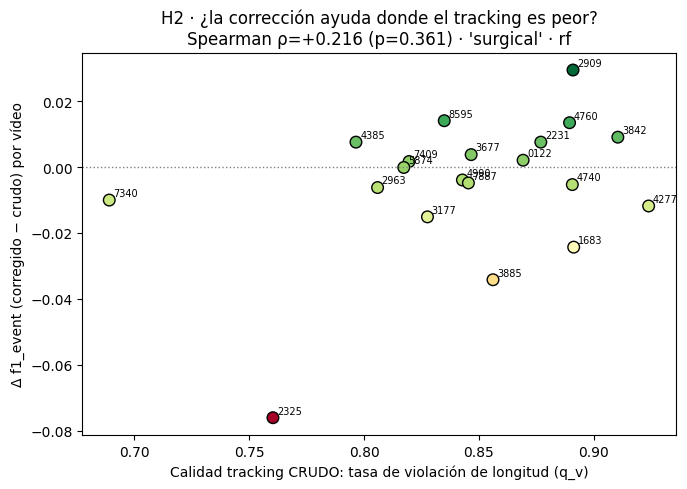


Paso 2 — modelo con gate (τ ajustado sólo en train, señal q label-free):
 test_video        q    tau  f1_event_raw  f1_event_corr  f1_event_gated routed
 1185502231 0.876890 0.8561        0.5271         0.5347          0.5347   corr
 1296577409 0.819560 0.8561        0.2579         0.2596          0.2579    raw
 1495692909 0.890931 0.9238        0.5389         0.5684          0.5389    raw
 1522870122 0.869158 0.8561        0.5098         0.5119          0.5119   corr
 1682584277 0.923787 0.8561        0.4448         0.4330          0.4330   corr
  169344990 0.842806 0.8561        0.5994         0.5955          0.5994    raw
 1733083885 0.856089 0.8276        0.6039         0.5697          0.5697   corr
 1767632325 0.760370 0.8561        0.2365         0.1604          0.2365    raw
 1817903677 0.846567 0.8561        0.1057         0.1095          0.1057    raw
 1842114740 0.890555 0.8561        0.4723         0.4670          0.4670   corr
 2097395874 0.817350 0.8561        0.5739     

In [40]:
# ── Does the correction help CONDITIONALLY? (gating on tracking quality) ─────
# Self-contained; this used to live in a script. By default it LOADS the cached
# CSVs; RECOMPUTE=True redoes the H2 study, steps 0 to 2, about 6 min per variant.
# NOTE: the axis labels and title below stay in Spanish on purpose. The figure is
# used by the dissertation, which is not distributed here.
import sys, json, pathlib
_r = pathlib.Path.cwd()
while _r != _r.parent and not (_r/'src').exists(): _r = _r.parent
sys.path.insert(0, str(_r)) if str(_r) not in sys.path else None
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import spearmanr

RECOMPUTE = False
VARIANT, MODEL = "surgical", "rf"     # correction arm (the least harmful) + model
LAB = "CalMS21_task1"
RES = _r / "results"; RES.mkdir(exist_ok=True)
FEAT = _r / "dataset" / "features"
_step1 = RES / f"gated_step1_{VARIANT}_{MODEL}.csv"
_step2 = RES / f"gated_step2_{VARIANT}_{MODEL}.csv"
_verd  = RES / f"gated_verdict_{VARIANT}_{MODEL}.csv"

if RECOMPUTE or not (_step1.exists() and _step2.exists() and _verd.exists()):
    from sklearn.model_selection import LeaveOneGroupOut
    from src.evaluation.lovo import load_event_cache, evaluable_class_ids, fold_metrics, run_tree
    from src.data.loader import load_tracking, load_annotations
    from src.skeleton.mouse_skeleton import build_skeleton, fit_skeleton
    from src.skeleton.keypoint_smoother import violation_rate
    from src.skeleton.metrics import bootstrap_ci, paired_wilcoxon
    from src.eval.mabe_metric import windows_to_submission, solution_from_annotations, mouse_fbeta_records
    cache_raw = FEAT / "CalMS21_task1_multi_20_event_raw.npz"
    cache_cor = FEAT / f"CalMS21_task1_multi_20_event_{VARIANT}.npz"

    def _poses(df, mid, kpi):
        s = df[df["mouse_id"] == mid]; fr = sorted(s["video_frame"].unique())
        P = np.full((len(fr), len(kpi), 2), np.nan); fi = {f: i for i, f in enumerate(fr)}
        s = s.copy(); s["_fi"] = s["video_frame"].map(fi); s["_ki"] = s["bodypart"].map(kpi)
        v = s[s["_fi"].notna() & s["_ki"].notna()]
        P[v["_fi"].astype(int), v["_ki"].astype(int), 0] = v["x"].values
        P[v["_fi"].astype(int), v["_ki"].astype(int), 1] = v["y"].values
        return P
    def q_violation(videos):
        out = {}
        for vid in videos:
            raw = load_tracking(vid, LAB); sk = build_skeleton(LAB); fit_skeleton(sk, raw)
            kpi = {kp: i for i, kp in enumerate(sk.keypoints)}
            out[str(vid)] = float(np.mean([violation_rate(_poses(raw, m, kpi), sk, kpi)
                                           for m in sorted(raw["mouse_id"].unique())]))
        return out
    def _sols(videos):
        d = {}
        for vid in videos:
            try: ann = load_annotations(vid, LAB)
            except Exception: ann = None
            if ann is None or len(ann) == 0: d[str(vid)] = None; continue
            tr = {f"{int(r['agent_id'])},{'self' if r['target_id']==r['agent_id'] else int(r['target_id'])},{r['action']}"
                  for r in ann.to_dict("records")}
            d[str(vid)] = (ann, json.dumps(sorted(tr)))
        return d
    def _ef1(v, te, pred, classes, vids, ev, sols):
        e = sols.get(str(v))
        if e is None: return float("nan")
        sub = windows_to_submission(vids[te], ev["agent"][te], ev["target"][te],
                                    ev["fstart"][te], ev["fstop"][te],
                                    np.array([classes[p] for p in pred], dtype=object))
        return 0.0 if not sub else mouse_fbeta_records(
            solution_from_annotations(e[0], str(v), LAB, e[1]), sub)

    Xr, y, vids, classes, ev = load_event_cache(cache_raw)
    Xc, *_ = load_event_cache(cache_cor)
    nC = len(classes); sols = _sols(sorted(set(vids.tolist())))
    qmap = q_violation(sorted(set(vids.tolist())))
    # Step 1: paired per-fold f1_event (raw vs corr)
    rows = []
    for arm, Xf in (("raw", Xr), ("corr", Xc)):
        for tr, te in LeaveOneGroupOut().split(Xf, y, groups=vids):
            v = vids[te][0]; pred, _ = run_tree(MODEL, Xf[tr], y[tr], Xf[te])
            rows.append({"arm": arm, "test_video": str(v),
                         "f1_event": _ef1(v, te, pred, classes, vids, ev, sols)})
    pf = pd.DataFrame(rows).pivot(index="test_video", columns="arm", values="f1_event")
    pf["delta"] = pf["corr"] - pf["raw"]
    pf["q_violation"] = pd.Series(qmap)
    pf.round(4).to_csv(_step1)
    # Step 2: gate (train-tuned tau on label-free q)
    uniq = sorted(set(vids.tolist())); per = []
    for v in uniq:
        te = np.where(vids == v)[0]; tr = np.where(vids != v)[0]
        pr = run_tree(MODEL, Xr[tr], y[tr], Xr[te])[0]; pc = run_tree(MODEL, Xc[tr], y[tr], Xc[te])[0]
        per.append({"test_video": str(v), "q": qmap[str(v)],
                    "f_raw": _ef1(v, te, pr, classes, vids, ev, sols),
                    "f_cor": _ef1(v, te, pc, classes, vids, ev, sols)})
    pdf = pd.DataFrame(per); out = []
    for _, rr in pdf.iterrows():
        tr_ = pdf[pdf.test_video != rr.test_video]; cand = sorted(tr_.q.tolist())
        best_tau, best = cand[0] - 1e-9, -1.0
        for tau in [cand[0] - 1e-9] + cand:
            mv = float(np.nanmean(np.where(tr_.q.values > tau, tr_.f_cor.values, tr_.f_raw.values)))
            if mv > best: best, best_tau = mv, tau
        uc = rr.q > best_tau
        out.append({"test_video": rr.test_video, "q": round(rr.q, 4), "tau": round(best_tau, 4),
                    "f1_event_raw": round(rr.f_raw, 4), "f1_event_corr": round(rr.f_cor, 4),
                    "f1_event_gated": round(rr.f_cor if uc else rr.f_raw, 4),
                    "routed": "corr" if uc else "raw"})
    gdf = pd.DataFrame(out); gdf.to_csv(_step2, index=False)
    def _v(a, b, name):
        m = np.isfinite(a) & np.isfinite(b); a, b = np.asarray(a)[m], np.asarray(b)[m]; d = b - a
        lo, hi = bootstrap_ci(d, statistic="mean"); w = paired_wilcoxon(a, b)
        return {"comparison": name, "n": int(len(d)), "mean_a": round(float(a.mean()), 4),
                "mean_b": round(float(b.mean()), 4), "delta": round(float(d.mean()), 4),
                "ci_lo": round(float(lo), 4), "ci_hi": round(float(hi), 4),
                "wilcoxon_p": round(float(w["p_value"]), 4),
                "significant": bool((lo > 0 or hi < 0) and w["significant"])}
    pd.DataFrame([_v(gdf.f1_event_raw.values, gdf.f1_event_corr.values, "corr - raw"),
                  _v(gdf.f1_event_raw.values, gdf.f1_event_gated.values, "gated - raw")]).to_csv(_verd, index=False)
    print("(recalculado y cacheado)")

# ── Display, reading back the CSVs ───────────────────────────────────────────
piv = pd.read_csv(_step1, index_col=0)
mask = piv["delta"].notna() & piv["q_violation"].notna()
rho, pval = spearmanr(piv.loc[mask, "q_violation"], piv.loc[mask, "delta"])
print(f"Step 1 - correction '{VARIANT}' vs raw ({MODEL}, 20 LOVO folds)")
print(f"  f1_event crudo = {piv['raw'].mean():.4f} | corr = {piv['corr'].mean():.4f} "
      f"(delta medio = {piv['delta'].mean():+.4f})")
print(f"  Spearman(q_violation, delta) = {rho:+.3f}  p={pval:.3f}  [H2 requiere rho>0]")
fig, ax = plt.subplots(figsize=(7, 5)); ax.axhline(0, color="grey", lw=1, ls=":")
ax.scatter(piv.loc[mask, "q_violation"], piv.loc[mask, "delta"],
           c=piv.loc[mask, "delta"], cmap="RdYlGn", s=70, edgecolor="k")
for v, rr in piv[mask].iterrows():
    ax.annotate(str(v)[-4:], (rr["q_violation"], rr["delta"]), fontsize=7,
                xytext=(3, 3), textcoords="offset points")
ax.set_xlabel("Calidad tracking CRUDO: tasa de violación de longitud (q_v)")
ax.set_ylabel("Δ f1_event (corregido − crudo) por vídeo")
ax.set_title(f"H2 · ¿la corrección ayuda donde el tracking es peor?\n"
             f"Spearman ρ={rho:+.3f} (p={pval:.3f}) · '{VARIANT}' · {MODEL}")
plt.tight_layout(); plt.savefig(RES / "gated_correction_scatter.png", dpi=150, bbox_inches="tight"); plt.show()
print("\nStep 2 - gated model (tau tuned on train only, q is a label-free signal):")
print(pd.read_csv(_step2).to_string(index=False))
print(); print(pd.read_csv(_verd).to_string(index=False))

## §A6b Tracking quality as a first-order factor

CalMS21 ships curated, clean tracking, so the correction has few errors to fix,
which is most of why §A4 and §A6 come out flat. A real auto-labelling pipeline runs
a pose detector over raw video and produces identity swaps, dropouts and jitter,
exactly the errors the correction targets.

This section simulates that regime: realistic detector noise is injected into the
20 videos, and `f1_event` is compared between **noisy raw** and **noisy corrected**,
with the same noise in both so only the correction differs. Clean raw is the
reference.

**The positive, reportable finding:** the noise costs **23% of `f1_event`**, 0.53
down to 0.41. Tracking quality is a first-order factor, which is what motivates the
problem the correction was built for.

**But the correction still does not recover it**, even here: Δ is about -0.01 and
not significant. It helps some videos (867864385 +0.04, 87423842 +0.065) and harms
as many others. The lever is a better detector or more data, not geometric
post-correction.

In [41]:
# ── Tracking quality as a first-order factor (detector noise) ────────────────
# Does the correction recover f1_event when the tracking is NOISY, that is, in a
# realistic detector regime? Self-contained; this used to live in a script.
# By default it LOADS the cached CSV. RECOMPUTE=True rebuilds the noisy caches,
# injecting noise and correcting 20 videos, about 1.5 h, then re-evaluates.
import sys, json, time, pathlib
_r = pathlib.Path.cwd()
while _r != _r.parent and not (_r/'src').exists(): _r = _r.parent
sys.path.insert(0, str(_r)) if str(_r) not in sys.path else None
import numpy as np, pandas as pd

RECOMPUTE = False
LAB = "CalMS21_task1"
RES = _r / "results"; RES.mkdir(exist_ok=True)
FEAT = _r / "dataset" / "features"
CSV = RES / "noisy_tracking_correction.csv"
OUT_RAW = FEAT / "CalMS21_task1_multi_20_event_noisyraw.npz"
OUT_COR = FEAT / "CalMS21_task1_multi_20_event_noisycorr.npz"
NOISE = dict(noise_std=5.0, dropout_rate=0.05, swap_prob=0.02,
             speed_spikes_prob=0.03, drift_amplitude=15.0)   # realistic detector profile

def _build_and_eval():
    from src.data import features as F
    from src.data.features import extract_features
    from src.data.loader import load_tracking, load_annotations
    from src.skeleton.mouse_skeleton import build_skeleton, fit_skeleton
    from src.skeleton.keypoint_smoother import smooth_video
    from src.skeleton.config import skeleton_smooth_kwargs
    from src.skeleton.metrics import inject_corruption
    from src.eval.mabe_metric import window_frame_spans
    d = np.load(FEAT / "CalMS21_task1_multi_20_event.npz", allow_pickle=True)
    classes = [str(c) for c in d["classes"]]; videos = sorted(set(str(v) for v in d["video_ids"]))
    cti = {c: i for i, c in enumerate(classes)}; sk_kw = skeleton_smooth_kwargs()

    def _collect(track, sk, ann, vid):
        rows = []; res = extract_features(track, sk, ann); mice = sorted(res.keys())
        for mid in mice:
            r = res[mid]; Xm, ym, fdf = r["X"], r["y"], r["features_df"]
            if Xm is None or len(Xm) == 0 or ym is None: continue
            spans = window_frame_spans(fdf, F.WINDOW_SIZE, F.STRIDE, F.MIN_WINDOW_FILL)
            if len(spans) != len(Xm): continue
            other = next((m for m in mice if m != mid), -1) if len(mice) == 2 else -1
            for i in range(len(Xm)):
                lab = str(ym[i])
                if lab not in cti: continue
                rows.append((Xm[i], cti[lab], str(vid), int(mid), int(other), spans[i][0], spans[i][1]))
        return rows

    raw_rows, cor_rows = [], []
    for k, vid in enumerate(videos):
        t0 = time.time(); clean = load_tracking(vid, LAB)
        try: ann = load_annotations(vid, LAB); ann = ann if ann is not None and len(ann) else None
        except Exception: ann = None
        noisy = inject_corruption(clean, rng=np.random.default_rng(42 + k), **NOISE)
        sk = build_skeleton(LAB); fit_skeleton(sk, noisy)
        raw_rows += _collect(noisy, sk, ann, vid)
        corrected, _ = smooth_video(noisy, LAB, skeleton=sk, **sk_kw)
        cor_rows += _collect(corrected, sk, ann, vid)
        print(f"  {vid}: raw={len(raw_rows)} cor={len(cor_rows)} ({time.time()-t0:.0f}s)")

    def _save(rows, out):
        Xs, ys, vv, ag, tg, fs, fe = zip(*rows)
        np.savez_compressed(out, X=np.asarray(Xs, np.float32), y=np.asarray(ys, np.int64),
            video_ids=np.asarray(vv, object), classes=np.asarray(classes),
            win_agent=np.asarray(ag, np.int64), win_target=np.asarray(tg, np.int64),
            win_fstart=np.asarray(fs, np.int64), win_fstop=np.asarray(fe, np.int64))
    _save(raw_rows, OUT_RAW); _save(cor_rows, OUT_COR)
    return _eval()

def _eval():
    from sklearn.model_selection import LeaveOneGroupOut
    from src.evaluation.lovo import (load_event_cache, evaluable_class_ids, fold_metrics,
                                     run_tree, event_f1_for_fold)
    def lovo(cache):
        X, y, vids, classes, ev = load_event_cache(cache); nC = len(classes)
        eids = evaluable_class_ids(y, vids, classes); rows = []
        for tr, te in LeaveOneGroupOut().split(X, y, groups=vids):
            tv = vids[te][0]; pred, _ = run_tree("rf", X[tr], y[tr], X[te])
            fev = event_f1_for_fold(LAB, tv, te, pred, classes, vids, ev)
            rows.append({"test_video": tv, "f1_event": round(fev, 4) if not np.isnan(fev) else np.nan})
        return pd.DataFrame(rows)
    dr = lovo(OUT_RAW).rename(columns={"f1_event": "noisy_raw"})
    dc = lovo(OUT_COR).rename(columns={"f1_event": "noisy_corr"})
    m = dr.merge(dc, on="test_video")
    clean = FEAT / "CalMS21_task1_multi_20_event_raw.npz"
    if clean.exists():
        m = m.merge(lovo(clean).rename(columns={"f1_event": "clean_raw"}), on="test_video", how="left")
    m.round(4).to_csv(CSV, index=False); return m

if RECOMPUTE or not CSV.exists():
    print("Rebuilding the noisy caches and evaluating (about 1.5 h)…" if RECOMPUTE else
          "CSV absent; evaluating the noisy caches…")
    m = _build_and_eval() if (RECOMPUTE or not (OUT_RAW.exists() and OUT_COR.exists())) else _eval()
else:
    m = pd.read_csv(CSV)
    print("(loaded from the cached CSV; RECOMPUTE=True to rebuild, about 1.5 h)")

from src.skeleton.metrics import bootstrap_ci, paired_wilcoxon
a, b = m["noisy_raw"].to_numpy(), m["noisy_corr"].to_numpy()
msk = np.isfinite(a) & np.isfinite(b); a, b = a[msk], b[msk]; delta = b - a
lo, hi = bootstrap_ci(delta, statistic="mean"); w = paired_wilcoxon(a, b)
print("=== Does the correction recover f1_event on NOISY tracking? (20-fold LOVO, rf) ===")
if "clean_raw" in m: print(f"  clean-raw (reference)  f1_event = {m['clean_raw'].mean():.4f}")
print(f"  noisy-raw              f1_event = {a.mean():.4f}")
print(f"  noisy-corrected        f1_event = {b.mean():.4f}")
print(f"  delta (corr minus raw, noisy)   = {delta.mean():+.4f}  "
      f"CI[{lo:.4f},{hi:.4f}] p={w['p_value']:.4f}")
if "clean_raw" in m:
    _cost = m["clean_raw"].mean() - a.mean()
    print(f"\n  COST OF THE NOISE: {m['clean_raw'].mean():.3f} -> {a.mean():.3f} = "
          f"-{_cost:.3f} ({100*_cost/m['clean_raw'].mean():.0f}% relative), so tracking "
          "quality is a FIRST-ORDER factor. The correction does not recover it on net: it "
          "helps a subset of videos and harms others.")

(cargado de CSV cacheado; RECOMPUTE=True para reconstruir ≈1.5 h)
=== ¿Recupera la corrección f1_event con tracking RUIDOSO? (20-fold LOVO, rf) ===
  clean-raw (referencia) f1_event = 0.5331
  noisy-raw              f1_event = 0.4114
  noisy-corrected        f1_event = 0.3989
  delta (corr − raw, ruidoso)     = -0.0125  CI[-0.0324,0.0057] p=0.2789

  COSTE DEL RUIDO: 0.533 → 0.411 = −0.122 (23% relativo) → la calidad del tracking es un factor de PRIMER ORDEN. La corrección no lo recupera en neto (ayuda a un subconjunto de vídeos, daña a otros).


## §A9 Cross-lab generalisation and noise-robust training

Two further checks, folded into this notebook from what used to be separate scripts.
Both load cached CSVs; `RECOMPUTE=True` recomputes them with a random forest over
aggregated features, which is fast.

- **(A) Cross-lab.** Train on one CalMS21 lab, test on the others, over the shared
  classes {sniff, attack, mount}, on raw tracking. The common behaviours **transfer
  well**, F1 0.68 to 0.86, sometimes above within-lab, and `task2` generalises best.
- **(B) Noise-robust training.** Augment training with tracking-like noise (jitter
  and dropout) and check whether it buys robustness at test time.

In [42]:
# ── Complementary analyses: cross-lab generalisation and noise-robust training ─
# Self-contained; these used to live in separate scripts.
# Loads the cached CSVs; RECOMPUTE=True recomputes, which is fast since it is a
# random forest over aggregated features.
import sys, pathlib
_r = pathlib.Path.cwd()
while _r != _r.parent and not (_r/'src').exists(): _r = _r.parent
sys.path.insert(0, str(_r)) if str(_r) not in sys.path else None
import numpy as np, pandas as pd
from sklearn.metrics import f1_score
from src.evaluation.lovo import aggregate_windows
from src.models.baseline import RandomForestBaseline

RECOMPUTE = False
RES = _r / "results"; FEAT = _r / "dataset" / "features"; SEED = 42
XLAB_CSV, NR_CSV = RES / "crosslab_matrix.csv", RES / "noise_robust_runs.csv"
LABS = ["CalMS21_task1", "CalMS21_task2", "CalMS21_supplemental"]
COMMON = ["sniff", "attack", "mount"]; CIDX = {c: i for i, c in enumerate(COMMON)}

# ── (A) cross-lab: train on one lab, test on the others, shared classes only ──
if RECOMPUTE or not XLAB_CSV.exists():
    def _load_lab(lab):
        d = np.load(FEAT / f"xlab_{lab}_raw.npz", allow_pickle=True)
        X = np.nan_to_num(d["X"].astype(np.float32)); classes = [str(c) for c in d["classes"]]
        nm = np.array([classes[i] for i in d["y"].astype(int)], dtype=object); keep = np.isin(nm, COMMON)
        return (aggregate_windows(X[keep]), np.array([CIDX[n] for n in nm[keep]], np.int64),
                d["video_ids"].astype(str)[keep])
    data = {lab: _load_lab(lab) for lab in LABS}; rows = []
    for tr in LABS:
        Xtr, ytr, vtr = data[tr]
        for te in LABS:
            Xte, yte, vte = data[te]
            if tr == te:
                vids = np.array(sorted(set(vtr))); rng = np.random.default_rng(SEED); rng.shuffle(vids)
                cut = max(1, int(0.7*len(vids))); m = np.isin(vtr, list(vids[:cut])); mt = np.isin(vtr, list(vids[cut:]))
                clf = RandomForestBaseline(seed=SEED); clf.fit(Xtr[m], ytr[m])
                f1 = f1_score(ytr[mt], clf.predict(Xtr[mt]), labels=[0,1,2], average="macro", zero_division=0)
            else:
                clf = RandomForestBaseline(seed=SEED); clf.fit(Xtr, ytr)
                f1 = f1_score(yte, clf.predict(Xte), labels=[0,1,2], average="macro", zero_division=0)
            rows.append({"train": tr, "test": te, "macro_f1": round(float(f1), 4)})
    pd.DataFrame(rows).to_csv(XLAB_CSV, index=False)

df_xl = pd.read_csv(XLAB_CSV)
mat = df_xl.pivot(index="train", columns="test", values="macro_f1").reindex(index=LABS, columns=LABS)
off = {tr: round(float(np.mean([mat.loc[tr, te] for te in LABS if te != tr])), 4) for tr in LABS}
print("=== (A) Cross-lab: train (rows) x test (cols) macro-F1 over {sniff,attack,mount} ===")
print(mat.to_string())
print("mean OFF-diagonal (best generaliser first):", {k: v for k, v in sorted(off.items(), key=lambda x: -x[1])})
print(f"  -> best generaliser: {max(off, key=off.get)}. The shared behaviours transfer")
print("     well between labs (F1 0.68-0.86, sometimes at or above within-lab), so the "
      "features are transferable.\n")

# ── (B) noise-robust training: does augmenting train with noise help? ────────
if RECOMPUTE or not NR_CSV.exists():
    from sklearn.model_selection import LeaveOneGroupOut
    from src.evaluation.lovo import (load_event_cache, evaluable_class_ids, event_f1_for_fold, fold_metrics)
    JIT, DROP, NAUG = 0.15, 0.10, 2
    X, y, vids, classes, ev = load_event_cache(FEAT / "CalMS21_task1_multi_20_event_raw.npz")
    nC = len(classes); eids = evaluable_class_ids(y, vids, classes)
    fstd = np.broadcast_to(X.reshape(-1, X.shape[-1]).std(0).astype(np.float32), X.shape[1:]).copy()
    rng = np.random.default_rng(SEED); rows = []
    def _aug(Xtr, ytr):
        Xs, ys = [Xtr], [ytr]
        for _ in range(NAUG):
            Xa = Xtr + rng.normal(0, 1, Xtr.shape).astype(np.float32) * (JIT*fstd)
            dm = rng.random((Xa.shape[0], Xa.shape[1])) < DROP; dm[:, 0] = False
            for t in range(1, Xa.shape[1]): Xa[dm[:, t], t, :] = Xa[dm[:, t], t-1, :]
            Xs.append(Xa.astype(np.float32)); ys.append(ytr)
        return np.concatenate(Xs, 0), np.concatenate(ys, 0)
    for fi, (tr, te) in enumerate(LeaveOneGroupOut().split(X, y, groups=vids)):
        tv = vids[te][0]
        for cond in ("baseline", "noise_aug"):
            Xtr, ytr = (X[tr], y[tr]) if cond == "baseline" else _aug(X[tr], y[tr])
            clf = RandomForestBaseline(seed=SEED); clf.fit(np.nan_to_num(aggregate_windows(Xtr)), ytr)
            pred = clf.predict(np.nan_to_num(aggregate_windows(X[te])))
            fev = event_f1_for_fold("CalMS21_task1", tv, te, pred, classes, vids, ev)
            rows.append({"cond": cond, "fold": fi, "f1_event": round(float(fev), 4) if not np.isnan(fev) else np.nan})
    pd.DataFrame(rows).to_csv(NR_CSV, index=False)

from src.skeleton.metrics import bootstrap_ci, paired_wilcoxon
df_nr = pd.read_csv(NR_CSV)
b = df_nr[df_nr.cond == "baseline"].sort_values("fold").f1_event.to_numpy()
a = df_nr[df_nr.cond == "noise_aug"].sort_values("fold").f1_event.to_numpy()
d = a - b; lo, hi = bootstrap_ci(d[np.isfinite(d)], statistic="mean"); w = paired_wilcoxon(b, a)
print("=== (B) Noise-robust training (train augmented with jitter+dropout) vs baseline ===")
print(f"  f1_event base={np.nanmean(b):.4f} aug={np.nanmean(a):.4f} delta={np.nanmean(d):+.4f} "
      f"CI=[{lo:+.4f},{hi:+.4f}] p={w['p_value']:.3f}")
print("  -> augmenting with noise does NOT help, being neutral to negative: the "
      "cross-video gap is one of data COVERAGE, not of robustness to noise.")

=== (A) Cross-lab: train (filas) × test (cols) macro-F1 sobre {sniff,attack,mount} ===
test                  CalMS21_task1  CalMS21_task2  CalMS21_supplemental
train                                                                   
CalMS21_task1                0.7239         0.8579                0.7208
CalMS21_task2                0.8195         0.8937                0.7713
CalMS21_supplemental         0.6789         0.6932                0.7957
mean OFF-diagonal (mejor generaliza): {'CalMS21_task2': 0.7954, 'CalMS21_task1': 0.7893, 'CalMS21_supplemental': 0.6861}
  -> mejor generaliza: CalMS21_task2. Los comportamientos comunes transfieren
     bien entre labs (F1 0.68-0.86, a veces >= within-lab): features transferibles.

=== (B) Noise-robust training (augmentar train con jitter+dropout) vs baseline ===
  f1_event base=0.5331 aug=0.5229 delta=-0.0102 CI=[-0.0261,+0.0036] p=0.409
  -> augmentar con ruido NO ayuda (neutral/negativo): el gap cross-vídeo es de COBERTURA de datos, no de